![image info](https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/images/banner_1.png)

# Proyecto 1 - Predicción de popularidad en canción

En este proyecto podrán poner en práctica sus conocimientos sobre modelos predictivos basados en árboles y ensambles, y sobre la disponibilización de modelos. Para su desarrollo tengan en cuenta las instrucciones dadas en la "Guía del proyecto 1: Predicción de popularidad en canción".

**Entrega**: La entrega del proyecto deberán realizarla durante la semana 4. Sin embargo, es importante que avancen en la semana 3 en el modelado del problema y en parte del informe, tal y como se les indicó en la guía.

Para hacer la entrega, deberán adjuntar el informe autocontenido en PDF a la actividad de entrega del proyecto que encontrarán en la semana 4, y subir el archivo de predicciones a la competencia de Kaggle cuyo link estará disponible en la sección del Coursera del proyecto.

## Datos para la predicción de popularidad en cancion

En este proyecto se usará el conjunto de datos de datos de popularidad en canciones, donde cada observación representa una canción y se tienen variables como: duración de la canción, acusticidad y tempo, entre otras. El objetivo es predecir qué tan popular es la canción. Para más detalles puede visitar el siguiente enlace: [datos](https://huggingface.co/datasets/maharshipandya/spotify-tracks-dataset).

## Ejemplo predicción conjunto de test para envío a Kaggle

En esta sección encontrarán el formato en el que deben guardar los resultados de la predicción para que puedan subirlos a la competencia en Kaggle.

In [1]:
# Predicción del conjunto de test - acá se genera un número aleatorio como ejemplo
#np.random.seed(42)
#y_pred = pd.DataFrame(np.random.rand(dataTesting.shape[0]) * 100, index=dataTesting.index, columns=['Popularity'])

# Guardar predicciones en formato exigido en la competencia de kaggle
#y_pred.to_csv('test_submission_file.csv', index_label='ID')
#y_pred.head()

In [2]:
# Importación librerías
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor, GradientBoostingRegressor
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from IPython.display import Markdown, display
from catboost import CatBoostRegressor, Pool
# from category_encoders import TargetEncoder
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
from sklearn import metrics
import missingno as msno
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
from flask import Flask
from flask_restx import Api, Resource, fields
import joblib

warnings.filterwarnings('ignore')

In [3]:
# Carga de datos de archivo .csv
dataTraining = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2026/main/datasets/dataTrain_Spotify.csv')
dataTesting = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2026/main/datasets/dataTest_Spotify.csv', index_col=0)

# 1. Preprocesamiento de datos

## 1.1 Verificación de duplicados

In [4]:
# Eliminamos los duplicados manteniendo la primera aparición
duplicados_train = dataTraining.duplicated().sum()
duplicados_test = dataTesting.duplicated().sum()
print(f"Número de registros con track_id duplicado para train: {duplicados_train} y para test: {duplicados_test}")

#Eliminar variables que no vamos a usar
TrainingDrop = [dataTraining.columns[0], 'Unnamed: 0', 'track_id']
data_Training = dataTraining.drop(columns=TrainingDrop)

TestDrop = [dataTesting.columns[0], 'track_id']
data_Testing = dataTesting.drop(columns=TestDrop)

Número de registros con track_id duplicado para train: 0 y para test: 40


## 1.2 Validación Valores Nulos

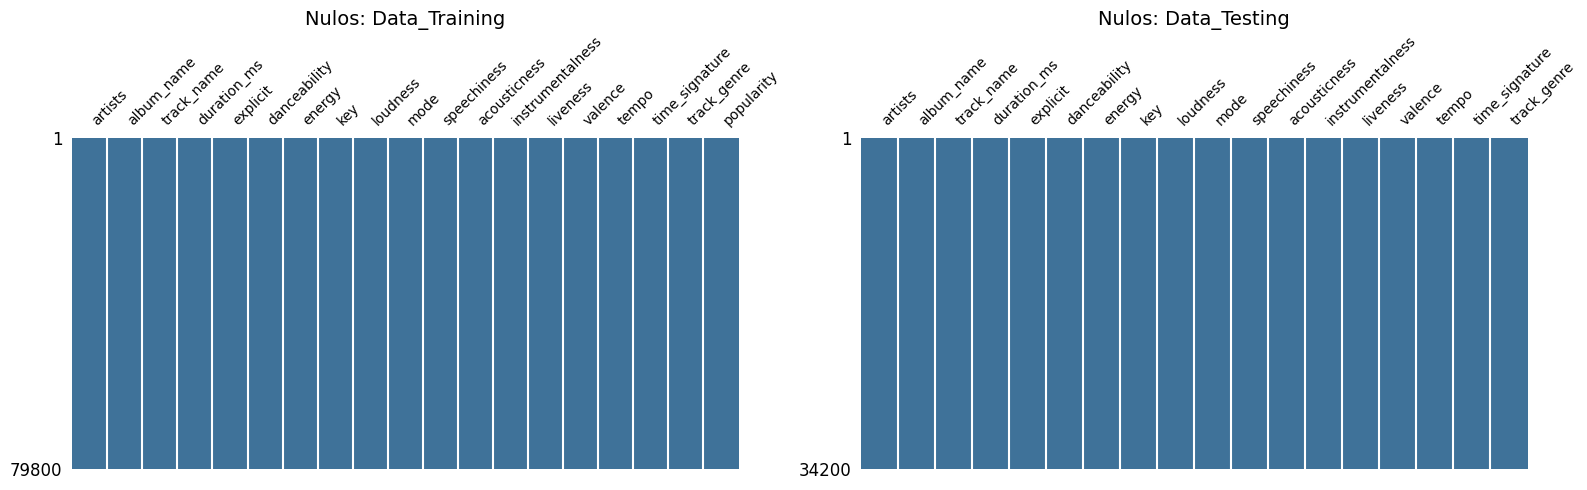

Se tienen 0 valores nulos en los datos de Training 

Se tienen 3 valores nulos en los datos de Testing 

,artists,album_name,track_name,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
7668,NaN,NaN,NaN,0,False,0.501,0.583,7,-9.46,0,0.0605,0.69,0.00396,0.0747,0.734,138.391,4,k-pop


Los valores nulos encontrados, se corrigen para mostrar ***Unknown***

Los nuevos valores nulos para los datos de Testing son 0 

In [5]:
#Se validan nulos
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
msno.matrix(data_Training, ax=ax[0], color=(0.25, 0.45, 0.6), fontsize=10, sparkline=False)
ax[0].set_title("Nulos: Data_Training", fontsize=14)
msno.matrix(data_Testing, ax=ax[1], color=(0.25, 0.45, 0.6), fontsize=10, sparkline=False)
ax[1].set_title("Nulos: Data_Testing", fontsize=14)
plt.tight_layout()
plt.show()

null_Training = data_Training.isnull().sum().sum()
nulos_Training = data_Training[data_Training.isnull().any(axis=1)]
display(Markdown(f"""Se tienen {null_Training} valores nulos en los datos de Training """))
null_Testing = data_Testing.isnull().sum().sum()

nulos_Testing = data_Testing[data_Testing.isnull().any(axis=1)]
display(Markdown(f"""Se tienen {null_Testing} valores nulos en los datos de Testing """))
display(nulos_Testing)

display(Markdown(f"""Los valores nulos encontrados, se corrigen para mostrar ***Unknown***"""))
data_Testing['artists'] = data_Testing['artists'].fillna('Unknown')
data_Testing['album_name'] = data_Testing['album_name'].fillna('Unknown')
data_Testing['track_name'] = data_Testing['track_name'].fillna('Unknown')

null_Testing = data_Testing.isnull().sum().sum()
nulos_Testing = data_Testing[data_Testing.isnull().any(axis=1)]
display(Markdown(f"""Los nuevos valores nulos para los datos de Testing son {null_Testing} """))

## 1.2 Revisión Comportamiento y valores de las variables

In [6]:
#Se clasifican las variables de acuerdo a su tipo
def clasificar_variables(df):
    variables_numericas = []
    variables_categoricas = []
    variables_categorica_numerica = []
    
    for col in df.columns:
        if df[col].dtype == 'object' or df[col].dtype.name == 'category':
            variables_categoricas.append(col)
        elif pd.api.types.is_numeric_dtype(df[col]):
            if df[col].nunique() <= 12: #Numero de valores de 'key'
                variables_categorica_numerica.append(col)
            else:
                variables_numericas.append(col)                                                                                                                 
            
    return variables_numericas, variables_categoricas, variables_categorica_numerica                                

var_numericas, var_categoricas, vars_cat_num = clasificar_variables(data_Training)

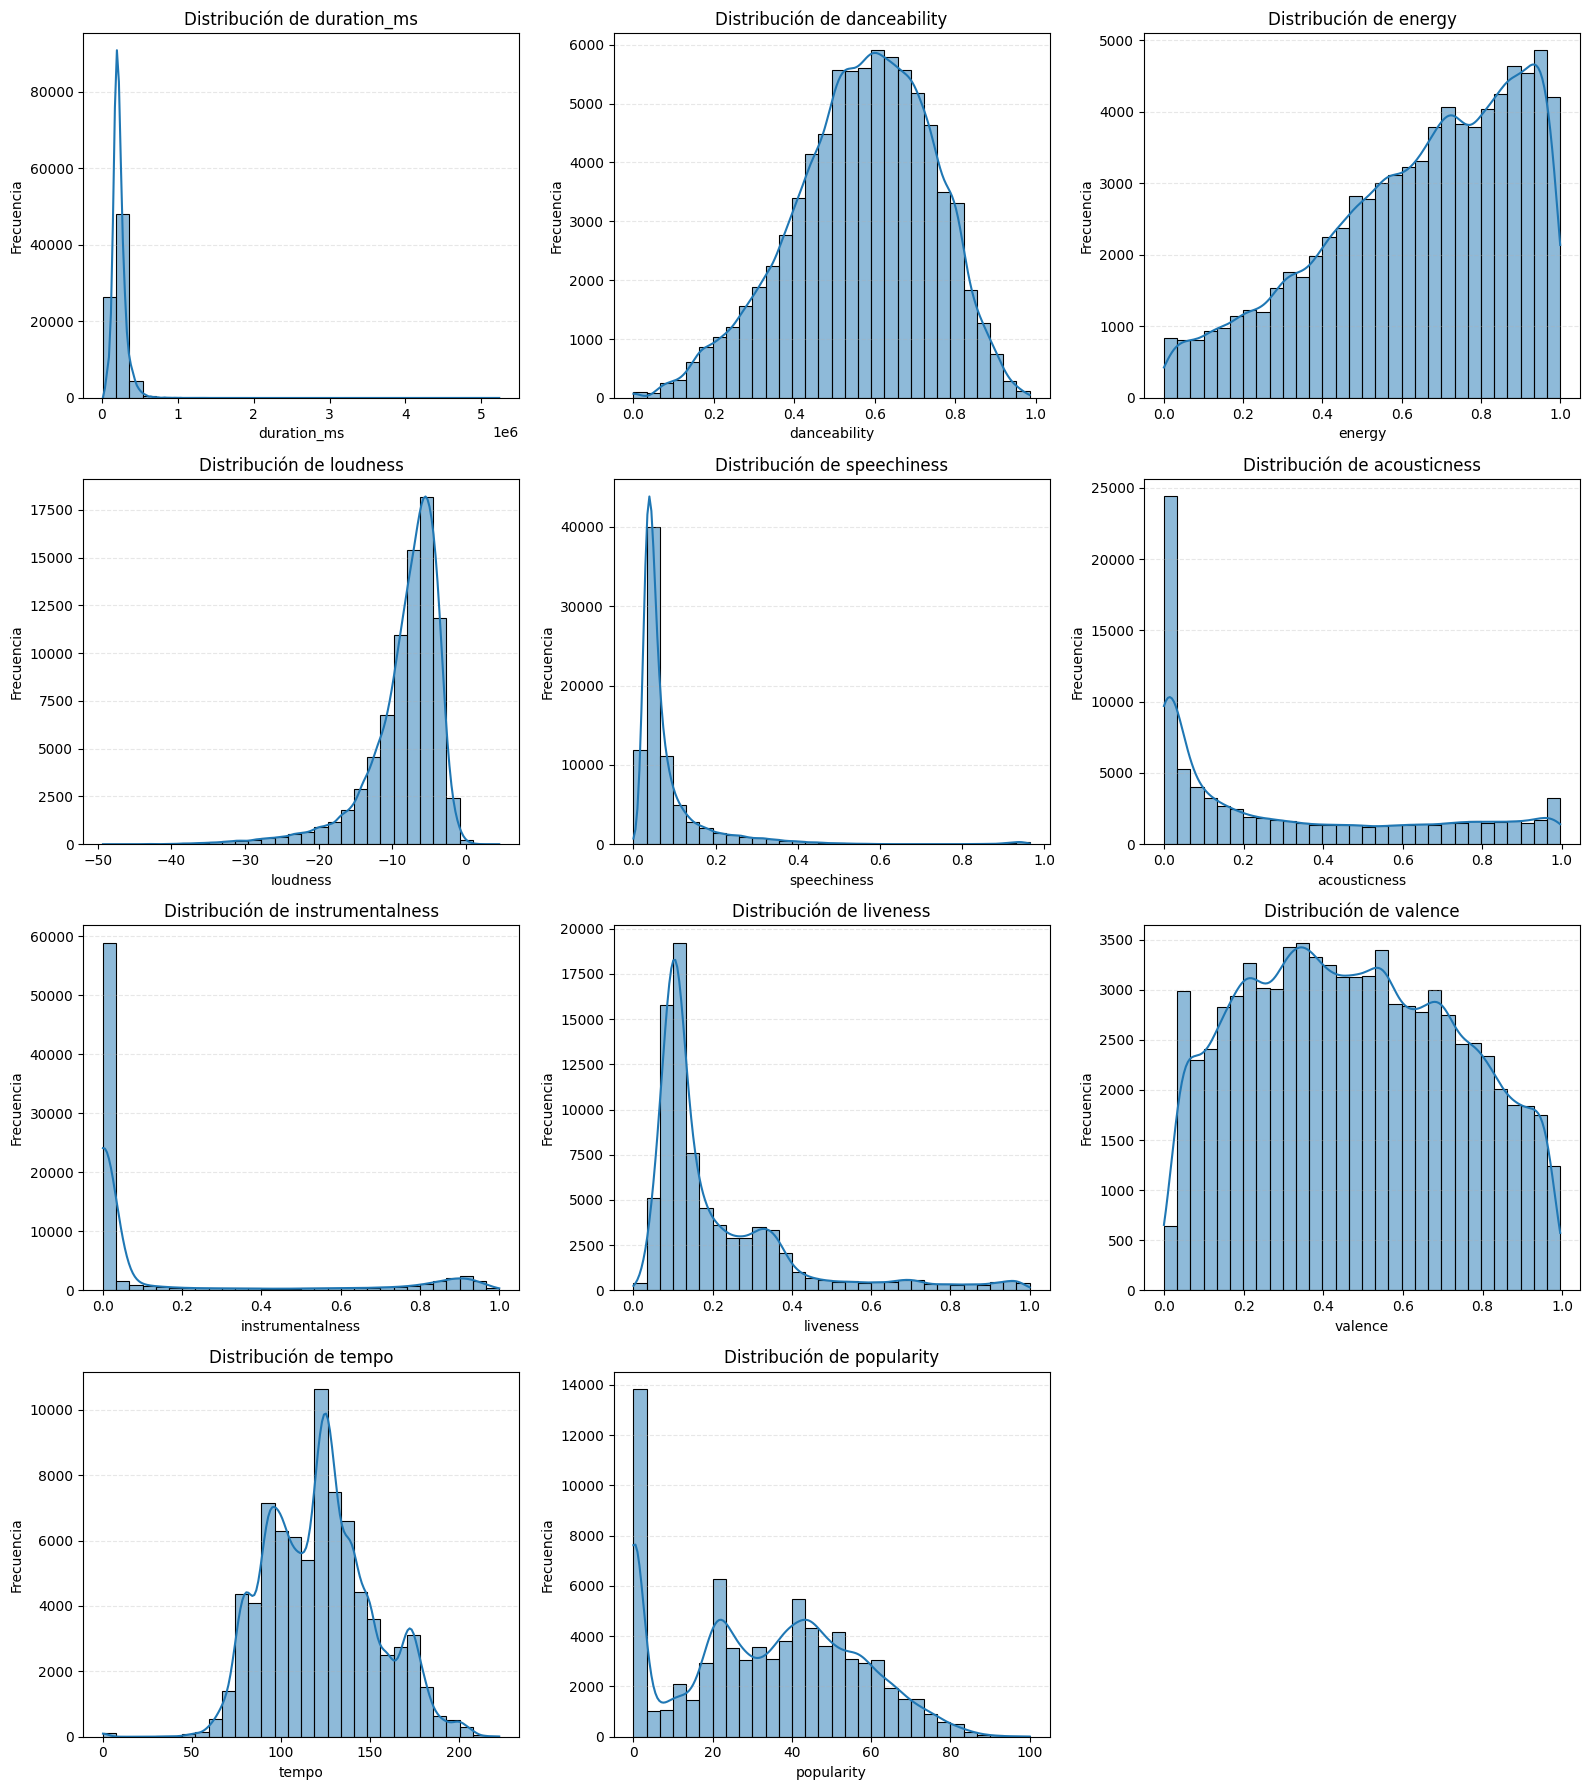

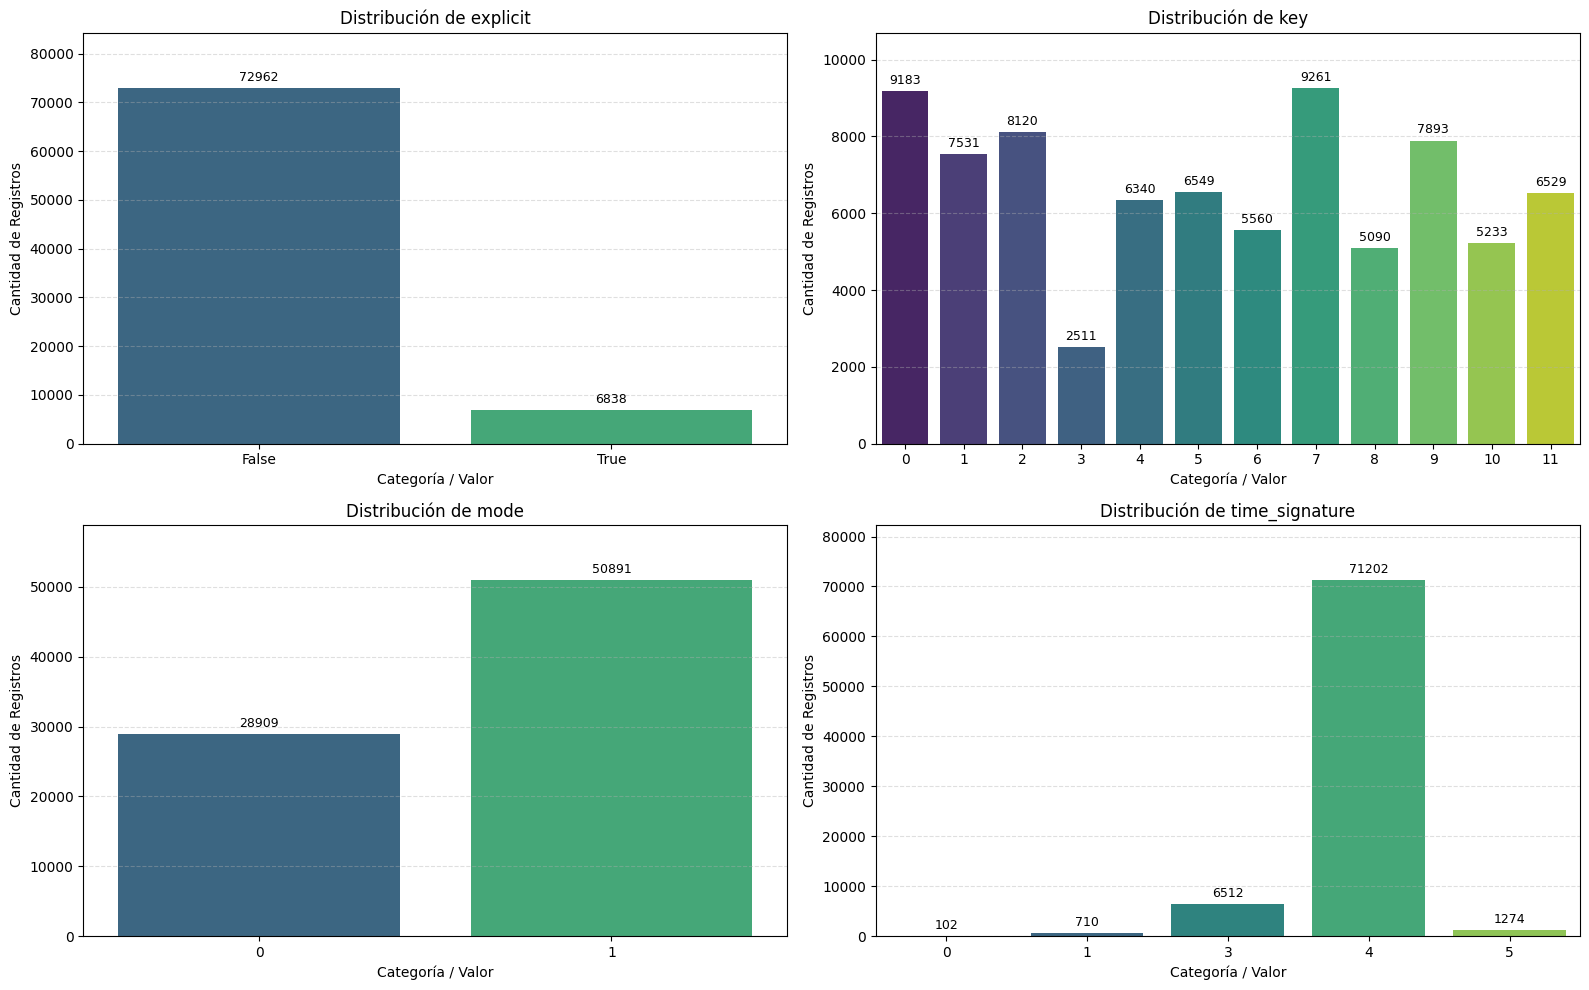

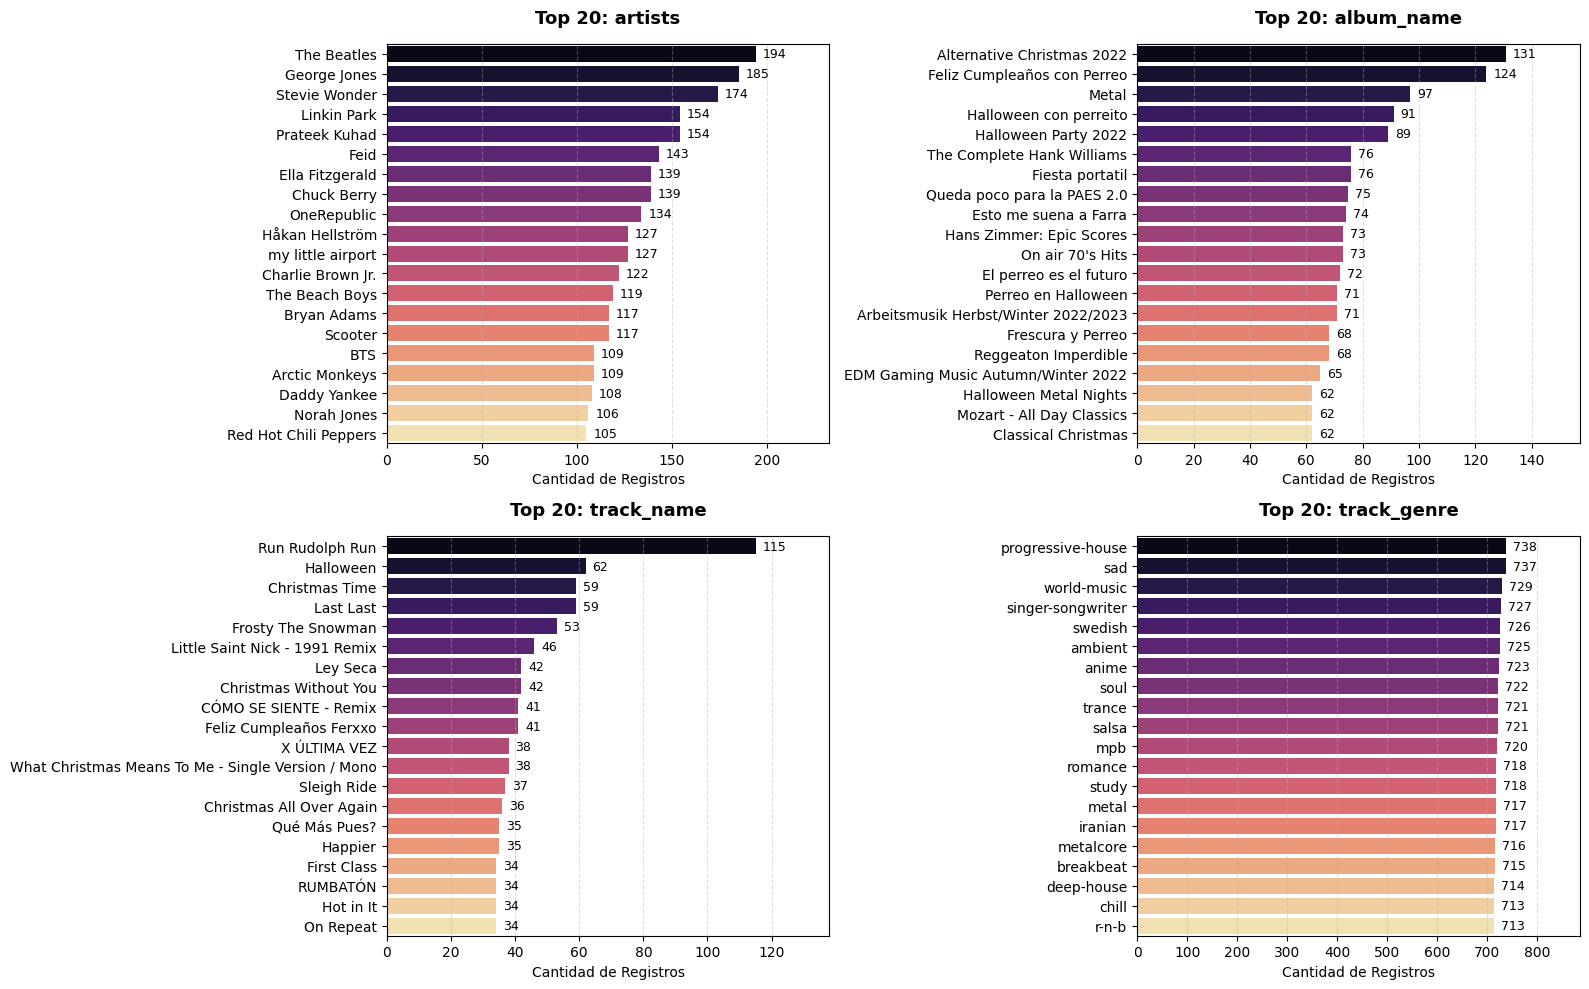

In [7]:
#Vemos el comportamiento de las varaiables numericas
plt.figure(figsize=(16, 18))
for i, var in enumerate(var_numericas):
    plt.subplot((len(var_numericas) + 2) // 3, 3, i + 1)
    sns.histplot(data_Training[var], kde=True, bins=30)
    plt.title(f'Distribución de {var}')
    plt.xlabel(var)
    plt.ylabel('Frecuencia')
    plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

#Vemos el comportamiento de las varaiables binarias
plt.figure(figsize=(16, 10))
for i, var in enumerate(vars_cat_num):
    ax = plt.subplot(2, 2, i + 1)
    sns.countplot(data=data_Training, x=var, palette='viridis', ax=ax)
    for container in ax.containers:
        ax.bar_label(container, padding=3, fontsize=9)
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.title(f'Distribución de {var}', fontsize=12)
    plt.xlabel('Categoría / Valor')
    plt.ylabel('Cantidad de Registros')
    ax.set_ylim(0, ax.get_ylim()[1] * 1.1)
plt.tight_layout()
plt.show()

#Vemos el comportamiento de las varaiables categóricas - top 20
plt.figure(figsize=(16, 10))
for i, var in enumerate(var_categoricas):
    ax = plt.subplot(2, 2, i + 1)
    top_values = data_Training[var].value_counts().head(20)
    sns.barplot(x=top_values.values, y=top_values.index, palette='magma', ax=ax)
    for container in ax.containers:
        ax.bar_label(container, padding=5, fontsize=9)
    ax.set_title(f'Top 20: {var}', fontsize=13, fontweight='bold', pad=15)
    ax.set_xlabel('Cantidad de Registros')
    ax.set_ylabel('')
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    ax.set_xlim(0, top_values.values.max() * 1.2)
plt.tight_layout()
plt.show()

## 1.3 Análisis mediante correlación - Mapa de calor

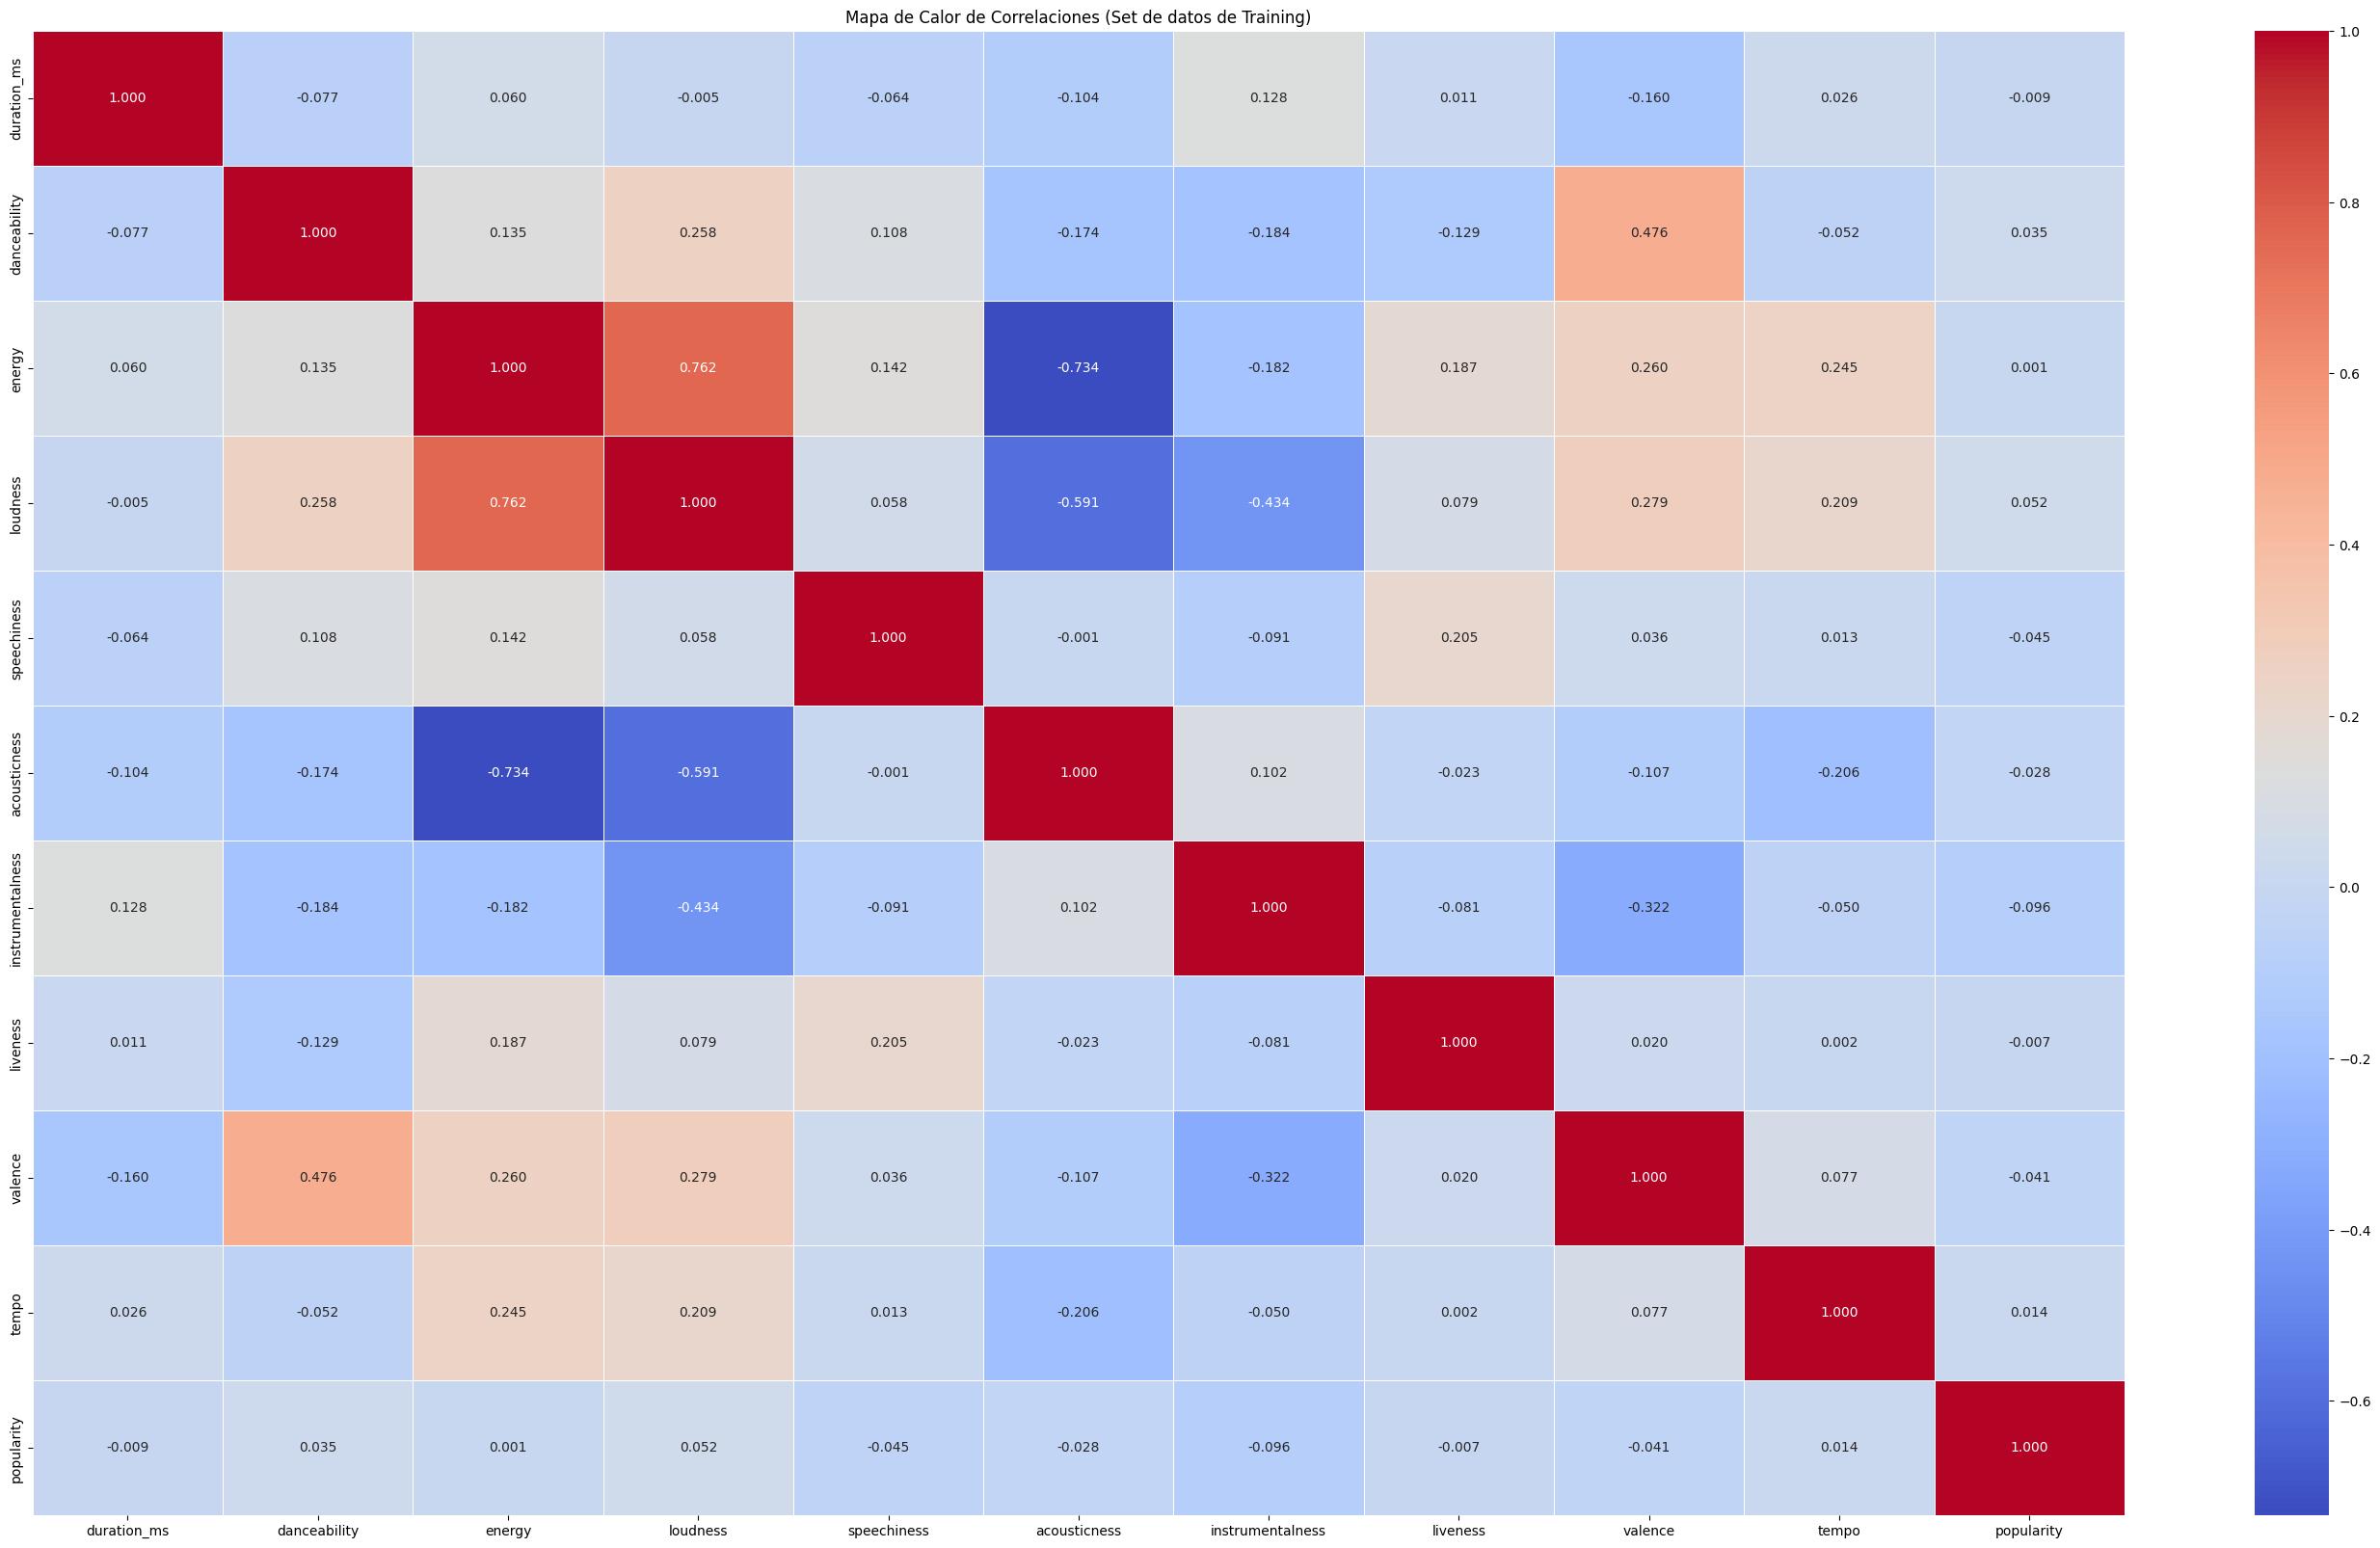

In [8]:
# Hacemos un mapa de calor de las variables numericas para poder ver las correlaciones entre ellas
plt.figure(figsize=(35, 20))
sns.heatmap(data_Training[var_numericas].corr(), annot=True, cmap = "coolwarm", fmt=".3f", linewidths = 0.5)
plt.title("Mapa de Calor de Correlaciones (Set de datos de Training)")
plt.show()

# Se puede observar que las variables energy - loudenss y acousticness - energy tiene correlaciones altas con valores de 0.7 y -0.7 respectivamente, las cuales se deciden dejar como están
# dado que no representan un problema para modelos basados en árboles de decisión. 

## 1.4 Análisis de estadísticas descriptivas

In [9]:
# Mostramos las estadísticas descriptivas de las variables del set de datos de Train
pd.set_option('display.max_columns', None)
display(data_Training.describe())

# La variable duration_ms tiene una escala muy grande, la cual puede generar problemas para algunos modelos (por ejemplo regresiones lineales), por lo que se pasa a minutos
data_Training['duration_min'] = data_Training['duration_ms'] / 60000
data_Testing['duration_min'] = data_Testing['duration_ms'] / 60000

# Eliminamos la columna original duration_ms
data_Training.drop(columns=['duration_ms'], inplace=True)
data_Testing.drop(columns=['duration_ms'], inplace=True)

pd.set_option('display.max_columns', None)
display(data_Training.describe())

,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,popularity
count,7.980000e+04,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000
mean,2.279022e+05,0.567318,0.641529,5.307043,-8.263741,0.637732,0.084750,0.314979,0.157319,0.213313,0.474267,122.076559,3.902556,33.265301
std,1.050599e+05,0.173110,0.251441,3.562186,5.035504,0.480659,0.105657,0.332512,0.310792,0.190075,0.259010,29.941937,0.434284,22.330871
min,1.338600e+04,0.000000,0.000019,0.000000,-49.307000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.744360e+05,0.456000,0.472000,2.000000,-10.006000,0.000000,0.035900,0.017000,0.000000,0.097900,0.261000,99.081250,4.000000,17.000000
50%,2.128130e+05,0.581000,0.685000,5.000000,-7.012000,1.000000,0.049000,0.169000,0.000041,0.132000,0.464000,122.009000,4.000000,35.000000
75%,2.614260e+05,0.695000,0.854000,8.000000,-5.000000,1.000000,0.084500,0.598000,0.050500,0.273000,0.684000,140.054000,4.000000,50.000000
max,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,222.605000,5.000000,100.000000


,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,popularity,duration_min
count,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000
mean,0.567318,0.641529,5.307043,-8.263741,0.637732,0.084750,0.314979,0.157319,0.213313,0.474267,122.076559,3.902556,33.265301,3.798370
std,0.173110,0.251441,3.562186,5.035504,0.480659,0.105657,0.332512,0.310792,0.190075,0.259010,29.941937,0.434284,22.330871,1.750998
min,0.000000,0.000019,0.000000,-49.307000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.223100
25%,0.456000,0.472000,2.000000,-10.006000,0.000000,0.035900,0.017000,0.000000,0.097900,0.261000,99.081250,4.000000,17.000000,2.907267
50%,0.581000,0.685000,5.000000,-7.012000,1.000000,0.049000,0.169000,0.000041,0.132000,0.464000,122.009000,4.000000,35.000000,3.546883
75%,0.695000,0.854000,8.000000,-5.000000,1.000000,0.084500,0.598000,0.050500,0.273000,0.684000,140.054000,4.000000,50.000000,4.357100
max,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,222.605000,5.000000,100.000000,87.288250


## 1.5 Ingeniería de Variables

In [10]:
#Creamos una vriable binaria que nos dice si la canción es de una colaboración o no: 1 si contiene ';', 0 si no.
data_Training['is_collaboration'] = data_Training['artists'].str.contains(';').astype(int)
data_Testing['is_collaboration'] = data_Testing['artists'].str.contains(';').astype(int)

# Convertimos a valores numericos los valores de la columna explicit
data_Training['explicit'] = data_Training['explicit'].astype(int)
data_Testing['explicit'] = data_Testing['explicit'].astype(int)

# Se dividen los datos en predictores y variable de interés
y_Training = data_Training['popularity']
X_Training = data_Training.drop(['popularity'], axis=1)

# Se dividen los datos de Training en Train y Validation
X_train, X_val, y_train, y_val = train_test_split(X_Training, y_Training, test_size=0.2, random_state=42)

In [11]:
# Creamos una variable que contenga el promedio de la popularidad por artista
# Para los casos en donde hay colaborciones, se "duplica" la columna, teniendo cada artista en una fila nueva y así calculando el promedio de popularidad de una mejor manera
train_exploded = X_train[['artists']].assign(artists=X_train['artists'].str.split(';')).explode('artists')
train_exploded['popularity'] = y_train 

# Se calcula el promedio de popularidad por artista
diccionario_artistas = train_exploded.groupby('artists')['popularity'].mean()
display(diccionario_artistas.head())

# Se calcula el promedio de popularidad general
global_mean = y_train.mean()

# Se asigna la popularidad promedio a cada artista como un valor en nueva columna. Se tienen 3 casos:
# 1. La canción pertencene a solo un artista, por lo que busca su popularidad promedio y se asigna ese valor
# 2. La canción pertence a más de un artista, por lo que sebusca la popularidad de cada artista de la colaboración y se promedia el resultado
# 3. La canción pertence a un artista que no esta en el set de datos de Train, para esos casos, se asigna el promedio global
                                                                                                      
def obtener_fama(lista_artistas):
    popularidad = [diccionario_artistas.get(a.strip(), global_mean) for a in lista_artistas]
    return sum(popularidad) / len(popularidad)

X_train['artist_popularity_avg'] = X_train['artists'].str.split(';').apply(obtener_fama)
X_val['artist_popularity_avg'] = X_val['artists'].str.split(';').apply(obtener_fama)
data_Testing['artist_popularity_avg'] = data_Testing['artists'].str.split(';').apply(obtener_fama)

display(Markdown(f"""Las traformaciones realizadas no generan data-leakage dentro dentro de los datos dado que algunas de ellas no contemplan la variable de interés dentro de
                los calculos, y otras como artist_popularity_avg la consideran pero solo usan los datos de entrenamiento, por lo que cuando se entrene un modelo, los datos de 
                validación y test no conocerán el comportamiento de la variable a predecir."""))

artists
!nvite                                         23.0
"Cats" 1983 Broadway Cast                      26.5
"Pepo" San Martín                              21.0
"Puppy Dog Pals" Cast                          55.0
"The Phantom Of The Opera" 1990 German Cast    24.0
Name: popularity, dtype: float64

Las traformaciones realizadas no generan data-leakage dentro dentro de los datos dado que algunas de ellas no contemplan la variable de interés dentro de
                los calculos, y otras como artist_popularity_avg la consideran pero solo usan los datos de entrenamiento, por lo que cuando se entrene un modelo, los datos de 
                validación y test no conocerán el comportamiento de la variable a predecir.

In [12]:
display(Markdown(f"""Para el análisis se usarán cuatro set de datos (A, B, C y D), cada uno con variaciones distintas, para poder obervar el impacto en las métricas de los modelos a 
                 entrenar y así poder definir cual de los dos se usará para la calibración del modelo final a implementar.."""))

#Set de datos A
X_train_A = X_train.copy()
X_val_A = X_val.copy()
x_test_A = data_Testing.copy()

#Set de datos B
X_train_B = X_train.copy()
X_val_B = X_val.copy()
x_test_B = data_Testing.copy()

#Set de datos C
X_train_C = X_train.copy()
X_val_C = X_val.copy()
x_test_C = data_Testing.copy()

#Set de datos D
X_train_D = X_train.copy()
X_val_D = X_val.copy()
x_test_D = data_Testing.copy()

Para el análisis se usarán cuatro set de datos (A, B, C y D), cada uno con variaciones distintas, para poder obervar el impacto en las métricas de los modelos a 
                 entrenar y así poder definir cual de los dos se usará para la calibración del modelo final a implementar..

## 1.5.1 Set de datos A

In [13]:
display(Markdown(f"""Para el set de datos A, se hara 1 transformacion; división de la variable genero en multiples variables, una por cada genero."""))

#Eliminamos las variales categoricas
X_train_A = X_train_A.drop(columns=['track_name', 'album_name','artists'])
X_val_A = X_val_A.drop(columns=['track_name', 'album_name','artists'])
x_test_A = x_test_A.drop(columns=['track_name', 'album_name','artists'])

# Creamos una variable para cada genero, para poder separar el impacto por género
X_train_A = X_train_A.join(pd.get_dummies(X_train_A['track_genre'], prefix='G', dtype=int))
X_val_A = X_val_A.join(pd.get_dummies(X_val_A['track_genre'], prefix='G', dtype=int))
x_test_A = x_test_A.join(pd.get_dummies(x_test_A['track_genre'], prefix='G', dtype=int))

# Eliminamos la columna original porque ya no la necesitamos
X_train_A.drop(columns=['track_genre'], inplace=True)
X_val_A.drop(columns=['track_genre'], inplace=True)
x_test_A.drop(columns=['track_genre'], inplace=True)

display(X_train_A.head())

Para el set de datos A, se hara 1 transformacion; división de la variable genero en multiples variables, una por cada genero.

,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,duration_min,is_collaboration,artist_popularity_avg,G_acoustic,G_afrobeat,G_alt-rock,G_alternative,G_ambient,G_anime,G_black-metal,G_bluegrass,G_blues,G_brazil,G_breakbeat,G_british,G_cantopop,G_chicago-house,G_children,G_chill,G_classical,G_club,G_comedy,G_country,G_dance,G_dancehall,G_death-metal,G_deep-house,G_detroit-techno,G_disco,G_disney,G_drum-and-bass,G_dub,G_dubstep,G_edm,G_electro,G_electronic,G_emo,G_folk,G_forro,G_french,G_funk,G_garage,G_german,G_gospel,G_goth,G_grindcore,G_groove,G_grunge,G_guitar,G_happy,G_hard-rock,G_hardcore,G_hardstyle,G_heavy-metal,G_hip-hop,G_honky-tonk,G_house,G_idm,G_indian,G_indie,G_indie-pop,G_industrial,G_iranian,G_j-dance,G_j-idol,G_j-pop,G_j-rock,G_jazz,G_k-pop,G_kids,G_latin,G_latino,G_malay,G_mandopop,G_metal,G_metalcore,G_minimal-techno,G_mpb,G_new-age,G_opera,G_pagode,G_party,G_piano,G_pop,G_pop-film,G_power-pop,G_progressive-house,G_psych-rock,G_punk,G_punk-rock,G_r-n-b,G_reggae,G_reggaeton,G_rock,G_rock-n-roll,G_rockabilly,G_romance,G_sad,G_salsa,G_samba,G_sertanejo,G_show-tunes,G_singer-songwriter,G_ska,G_sleep,G_songwriter,G_soul,G_spanish,G_study,G_swedish,G_synth-pop,G_tango,G_techno,G_trance,G_trip-hop,G_turkish,G_world-music
23491,0,0.383,0.836,3,-4.788,1,0.0468,0.1010,0.00000,0.2290,0.260,146.052,4,4.950000,1,51.847826,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
72887,0,0.608,0.592,0,-9.642,0,0.0409,0.4690,0.90900,0.0651,0.365,77.937,4,4.793767,0,47.000000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
54394,0,0.537,0.110,2,-25.941,1,0.0605,0.9910,0.84800,0.1190,0.890,124.812,4,1.344983,1,10.263981,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
43696,0,0.582,0.813,0,-4.558,1,0.0295,0.0819,0.00119,0.9020,0.345,109.934,4,4.452000,1,42.803030,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
45363,0,0.677,0.256,7,-16.915,1,0.0448,0.9480,0.00001,0.0926,0.318,103.986,4,2.616383,1,51.057143,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## 1.5.2 Set de datos B

In [14]:
display(Markdown(f"""Para el set de datos B, se dejarán las variables categóricas y el tratamiento de estas será distinto, dado que a todas se les aplicará un Frequency 
                 encoding."""))

mapas_frecuencias = {}

for col in var_categoricas:
    freq_map = X_train_B[col].value_counts(normalize=True).to_dict()
    mapas_frecuencias[col] = freq_map
    X_train_B[col + '_freq'] = X_train_B[col].map(freq_map)

#Aplicamos los cambios a Val y Test usando los datos de entrenamiento
for col in var_categoricas:
    X_val_B[col + '_freq'] = X_val_B[col].map(mapas_frecuencias[col])
    X_val_B[col + '_freq'] = X_val_B[col + '_freq'].fillna(0) # Si el genero es nuevo, se le pone 0

    x_test_B[col + '_freq'] = x_test_B[col].map(mapas_frecuencias[col])
    x_test_B[col + '_freq'] = x_test_B[col + '_freq'].fillna(0) # Si el genero es nuevo, se le pone 0

X_train_B.drop(columns=var_categoricas, inplace=True)
X_val_B.drop(columns=var_categoricas, inplace=True)
x_test_B.drop(columns=var_categoricas, inplace=True)

display(X_train_B.head())

Para el set de datos B, se dejarán las variables categóricas y el tratamiento de estas será distinto, dado que a todas se les aplicará un Frequency 
                 encoding.

,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,duration_min,is_collaboration,artist_popularity_avg,artists_freq,album_name_freq,track_name_freq,track_genre_freq
23491,0,0.383,0.836,3,-4.788,1,0.0468,0.1010,0.00000,0.2290,0.260,146.052,4,4.950000,1,51.847826,0.000047,0.000110,0.000016,0.009101
72887,0,0.608,0.592,0,-9.642,0,0.0409,0.4690,0.90900,0.0651,0.365,77.937,4,4.793767,0,47.000000,0.000016,0.000016,0.000031,0.008960
54394,0,0.537,0.110,2,-25.941,1,0.0605,0.9910,0.84800,0.1190,0.890,124.812,4,1.344983,1,10.263981,0.000689,0.000611,0.000016,0.008584
43696,0,0.582,0.813,0,-4.558,1,0.0295,0.0819,0.00119,0.9020,0.345,109.934,4,4.452000,1,42.803030,0.000047,0.000063,0.000047,0.008960
45363,0,0.677,0.256,7,-16.915,1,0.0448,0.9480,0.00001,0.0926,0.318,103.986,4,2.616383,1,51.057143,0.000031,0.000063,0.000031,0.009305


## 1.5.3 Set de datos C

In [15]:
encoder = TargetEncoder(cols=var_categoricas, smoothing=10)

X_train_C = encoder.fit_transform(X_train_C, y_train)
X_val_C= encoder.transform(X_val_C)
X_test_C = encoder.transform(x_test_C)

display(X_train_C.head())

NameError: name 'TargetEncoder' is not defined

## 1.5.4 Set de datos D

In [19]:
display(Markdown(f"""Para el set de datos D, no se hara ninguna transformación, se dejaran las variables intactas."""))

display(X_train_D.head())

Para el set de datos D, no se hara ninguna transformación, se dejaran las variables intactas.

,artists,album_name,track_name,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_min,is_collaboration,artist_popularity_avg
23491,Bethel Music;Emmy Rose,Victory (Live),Promises Never Fail - Live,0,0.383,0.836,3,-4.788,1,0.0468,0.1010,0.00000,0.2290,0.260,146.052,4,world-music,4.950000,1,51.847826
72887,Earl Klugh,Sudden Burst Of Energy,I'll Be Waiting,0,0.608,0.592,0,-9.642,0,0.0409,0.4690,0.90900,0.0651,0.365,77.937,4,guitar,4.793767,0,47.000000
54394,Wolfgang Amadeus Mozart;Danielle Laval,Mozart - Inspiring Classics,"9 Variations on a Minuet by J.P. Duport in D, ...",0,0.537,0.110,2,-25.941,1,0.0605,0.9910,0.84800,0.1190,0.890,124.812,4,classical,1.344983,1,10.263981
43696,Capital Inicial;Seu Jorge,Capital Inicial Acústico NYC (Ao Vivo) [Deluxe],À Sua Maneira (De Música Ligera) (feat. Seu Jo...,0,0.582,0.813,0,-4.558,1,0.0295,0.0819,0.00119,0.9020,0.345,109.934,4,r-n-b,4.452000,1,42.803030
45363,Rewind;Julia Alexa,Up All Night,Up All Night,0,0.677,0.256,7,-16.915,1,0.0448,0.9480,0.00001,0.0926,0.318,103.986,4,sad,2.616383,1,51.057143


In [ ]:
#Se validan los resultados obtenidos por varios modelos basados en arboles para cada set de datos (A y B)

#Dentro de los modelos se valida también el CatBoost, el cual esta diseñado para manejar variables categoricas sin problema
modelos = {
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42),
    "LightGBM": LGBMRegressor(verbose=-1, random_state=42),
    "RandomForest": RandomForestRegressor(random_state=42),
    "Bagging": BaggingRegressor(random_state=42),
    "DecisionTree": DecisionTreeRegressor(random_state=42)
}

datos = {
    "Set_A": (X_train_A, X_val_A),
    "Set_B": (X_train_B, X_val_B),
    "Set_C": (X_train_C, X_val_C),
    "Set_D": (X_train_D, X_val_D)
}

mse_val = {}
for datos, (X_tr, X_val) in datos.items():
    if datos == "Set_D":
        nombre = "CatBoost"
        modelo = CatBoostRegressor(random_state=42)
        train_pool = Pool(X_tr, y_train, cat_features=var_categoricas + vars_cat_num + ['is_collaboration'])
        modelo.fit(train_pool)
        y_pred = modelo.predict(X_val)
        mse = mean_squared_error(y_val, y_pred) 
        mse_val[f"{nombre}_{datos}"] = mse
    else:
        for nombre, modelo in modelos.items():
            modelo.fit(X_tr, y_train)
            y_pred = modelo.predict(X_val)
            mse = mean_squared_error(y_val, y_pred) 
            mse_val[f"{nombre}_{datos}"] = mse

Learning rate set to 0.078956
0:	learn: 21.2266046	total: 223ms	remaining: 3m 42s
1:	learn: 20.2279480	total: 448ms	remaining: 3m 43s
2:	learn: 19.3483472	total: 694ms	remaining: 3m 50s
3:	learn: 18.5487160	total: 962ms	remaining: 3m 59s
4:	learn: 17.8174035	total: 1.21s	remaining: 4m
5:	learn: 17.2086397	total: 1.43s	remaining: 3m 56s
6:	learn: 16.6466718	total: 1.64s	remaining: 3m 52s
7:	learn: 16.1440984	total: 1.91s	remaining: 3m 56s
8:	learn: 15.7166558	total: 2.11s	remaining: 3m 52s
9:	learn: 15.3464977	total: 2.32s	remaining: 3m 49s
10:	learn: 14.7229121	total: 2.49s	remaining: 3m 44s
11:	learn: 14.1863848	total: 2.65s	remaining: 3m 38s
12:	learn: 13.6975795	total: 2.77s	remaining: 3m 30s
13:	learn: 13.2755303	total: 2.93s	remaining: 3m 26s
14:	learn: 12.8981494	total: 3.07s	remaining: 3m 21s
15:	learn: 12.5347101	total: 3.28s	remaining: 3m 21s
16:	learn: 12.2319645	total: 3.4s	remaining: 3m 16s
17:	learn: 11.9632403	total: 3.53s	remaining: 3m 12s
18:	learn: 11.7245751	total: 3.

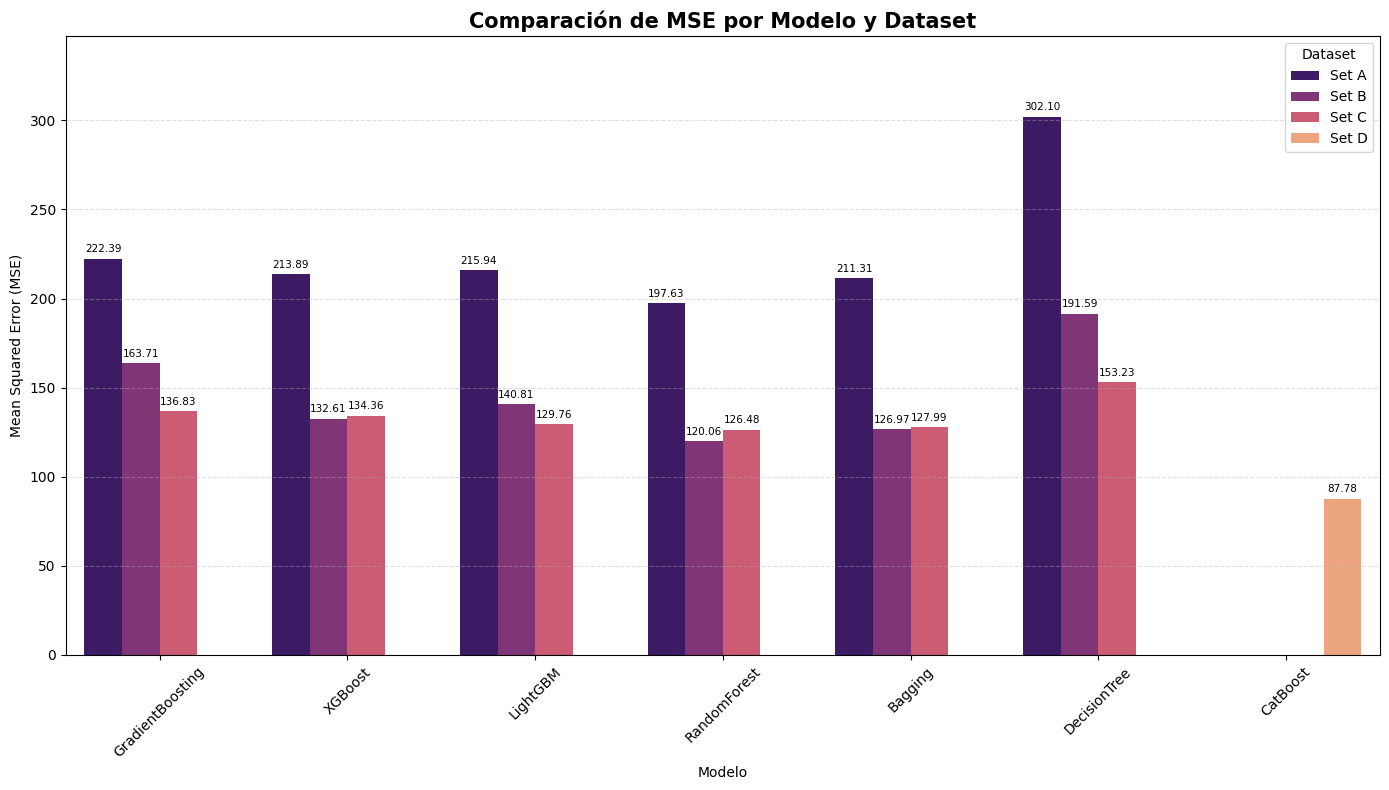

In [ ]:
df_mse_val = pd.DataFrame(list(mse_val.items()), columns=['Modelo_Set', 'MSE'])
df_mse_val[['Modelo', 'Dataset']] = df_mse_val['Modelo_Set'].str.split('_Set_', expand=True)
df_mse_val['Dataset'] = 'Set ' + df_mse_val['Dataset']
plt.figure(figsize=(14, 8))
ax = sns.barplot(data=df_mse_val, x='Modelo', y='MSE', hue='Dataset', palette='magma')

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=7.5, fmt='%.2f', rotation=0)

plt.title('Comparación de MSE por Modelo y Dataset', fontsize=15, fontweight='bold')
plt.ylabel('Mean Squared Error (MSE)')
plt.xlabel('Modelo')
plt.xticks(rotation=45)
ax.set_ylim(0, df_mse_val['MSE'].max() * 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

Para el preprocesamiento de los datos, primero se evalua la cantidad de duplicados para Train y test, seguido a esto, e eliminaron algunas columnas que no son de utilidad para la predicción de la popularidad de una canción, estas columnas fueron  'Unnamed: 0', 'track_id' para Training y  'track_id' para Testing (dado que este set de datos no trae 'Unnamed'). Adiconalmente, se establecio como estrategia generar 3 set de datos distintos, para los cuales se van a tener columnas y transformaciones comunes, pero también diferencias puntuales, para poder decidir cual set de datos y estrategia de preprocesamiento genera un mejor rendimiento. Por lo cual, se establecieron 6 pasos para completar el analisis y preparación de información:

1. **Eliminación de duplicados**: Para poder eliminar ruido proveniente de registros duplicados, se hace la evaluación d cuantos duplicados existen, viendo que en Train hay 0 y en test 40, por lo que se decide dejar la información como está.

2. **Validación Nulos**: Se revisaron los datos de los set de entreamiento y test en busca de valores nulos, mediante lo cual se indentificó que en el set de datos de testing tiene una observación en donde 'artists', 'album_name' y 'track_name' son nulos, por lo cual, estos valores se reemplazan con la palabra 'Unkonwn' para no generar problemas en la calibración y ejecución de los modelos.

3. **Revisión del comportamiento de ls variables**: Con la finalidad de entender de una mejor manera los datos con los que se están trabajando, se generan visualizaciones de los datos divididos en 3 categorías. 

    3.1 **Variables Numericas - Continuas**: Se crea un histograma para las variables de Train, en donde se inclye 'popularity' para poder obsrevar su comportamiento. 
    * De las variables se pudo ver que la mayoria tenia un sesgo hacia la izquierda, es decir que el set de datos cuenta con una cantidad de muestras grande que tienevalores bajos para variables como duratin_ms, speachiness, liveness entre otras.

    * Mediante variables como duration_ms se puede ver que la mayoria de canciones d spotify son cortas, sin embargo hay algunos pocos valores que tienen una duración mayor, por lo cual, los modelos basados en árboles serán una buena opción dado que estos son particularmente buenos con el manejo de outliers, como los observados en este caso.

    * Por último, en cuanto a la variable de interés (*popularity*), se puede ver que la mayoría de las observaciones en Train, tiene una popularidad baja o de 0. Lo cual, puede deberse a diversas razones, pero para terminos de la preparación de datos, se mantendra igual, dado que se asume que estos datos representan fenómenos reales y describen de manera acertada el comportamiento real de la relación de carcteríticas de una canción con la popularidad de la misma.

    3.2 **Variables Categoricas - Numericas y Binarias**: Se analiza cuantos registros existen para cada uno de los valores de cada variable. 
    * Se observa que para 'time_signature', la cual indica los tiempos del compás de la canción, se tiene una predominancia clara del tiempo 4, en donde se concentran la mayor parte de las observaciones, y que por el contrario tiempos como 0, tienen una presencia muy escasa dentro de las observaciones. Lo cual puede deberse a que comúmente el compás 0 no es usado o no existe en la práctica, por lo cual pueden ser errores de medición en la data, sin embargo, en algunos sistemas de medición y procesamiento digital, se pueden encontrar estos valores, por lo que se deján en el dataset, asumiendo que representan un fenómeno real y dad su presencia baja dentro del total de la infomación, con apenas 102 registros de 79800, aproximadamente 0.12%.

    * Para otras variables como 'explicit' se oberva que la mayoria de las canciones del set de datos de entranamiento corresponden a contenido NO explicito. POr otro lado, variables como 'mode', nos dejan ver que las pistas de las canciones están en mayor, es decir sonidos brillantes o alegres.

    3.3 **Variables Categóricas**: Se generan graficos de barras horizontales del top 20 valores, dado que estas variables tienen una cardinalidad muy alta y por ende, muchos valores distintos que resultan dificles de analizar en una sola gráfica. 
    * Dado que estas variables cuentan con bastantes valores distintos, resulta dificil analizarlas tal como están para modelos que acepten variables categoricas. Por otr lado, si se implementan modelos basados en arboes que usen únicamente variables numericas, estas variables tendrían que ser transformadas o eliminadas, pero en caso de ser trnsformadas, generian una cantidad masiva de columnas que llevaria a la maldición de la dimensionalidad, por lo cual, el exito del modelo dependerá en gran medida del manejo de las variables categóricas, las cuales tienen bastante información relevante.

    * La variable 'track_genre' cuenta con poco más de 100 categorías, en donde se puede ver que aparecen una cantidad de veces muy similar dentro del set de datos de train, indicando que hay una buena diversidad/balanceo de muestras para esta variable.

4. **Análisis mediante correlación - Mapa de calor**: Se analiza la correlación existente entre variables, en donde se puede observar que hay 3 variables que destacan con valores más altos dentro del mapa de calor, las cauales son 'energy', 'loudenss' y 'acousticness' con valores de 0.7 y -0.7 respectivamente, lo cual tiene sentido dado que los conceptos de las variables estan relacionados de por si y van de la mano. Sin embargo, hay modelos como los basados en arboles, que son robustos en el tratamiento de variables correlacionadas, dado que eligen una variable para hacer una partición y se escoge la que segmente de una mejor manera, capturando el efecto de las variables en los grupos creados después de los cortes/separaciones.

5. **Estadísticas descriptivas**: Se analizan los valores de las estadísticas descriptivas, en donde se puede ver que en general las variables cuentan con escalas consistentes, sin embargo hay puntos específicos que llaman la atención.
* La variable 'duration_ms' cuenta con una escala muy grande en comparación a las demás columnas, por lo cual, se decide transformarla a minutos, para que se pueda entender mejor en caso de requerise hacer análisis de las particiones creadas en arboles de decisión. También, se tiene en cuenta que los modelos basados en arboles no presentan problemas al manejar diferentes escalas, por lo cual no es necesario hacer un escalamiento o normalización si se van a usar, por lo cual se reitera que la transformación se hace para que el entendimiento de los datos/ y particiones finales pueda hacerse de una mejor manera (en caso de ser necesario).

* Se puede confirmar que la popularidad tiene valores diversos y pocos casos con popularidades altas, dado que si se observa el cuartil 75%, se ve que este tiene un valor de apenas 50, por lo cual el modelo calibrado podría tender a predecir más seguido valores de popularidad bajos.

6. **Ingeniería de variables**: Con la finalidad de mejorar la calidad de datos de entrenamiento para el modelo, se procede a generar variables basadas en las ya existentes que puedan generar valor, para ello se generan dos nuevas columnas. Adicional, se hace la transformación de una variable especifica.
* Se crea la columna 'is_collaboration', la cual contiene un 1 si en la variables 'artists' se detecta un ";", de lo contrario, pone un 0. 

* Se trasnforma la columa 'explicit', la cual contenia valores booleanos y se pasan a binarios, para que los modelos no tengan problemas procesando la información.

<div class="alert alert-block alert-info">
<b>Nota:</b> Después de hacer las transformaciones mencionadas, se hace una división del set de datos de entrenamiento en Train y Validation, con una proporción de 80/20. Esto con la finalidad de comprobar los consecuentes modelos antes de predecir las probabilidades finales con Test, asegurando así un paso de validación extra que sirva como filtro para posibles errores como overfitting.
</div>

* Se crea la variable 'artist_popularity_avg', la cual asigna un valor promedio de popularidad a una canción dependiendo de la popularidad promedio de un artista o una combinación de varios. Para ello, se crea un diccionario de popularidades por artista, basado **únicamente** en los valores de Train, pero aplicado a los set de datos de Train, Validation y test, en donde se plantean 3 casos.   
    * La canción pertenece a un único artista, el cual existe en el diccionario creado a partir de los datos de Train. Para este caso, se asigna la probabilidad de manera normal.
    * La canción pertence a más de un artista, por lo que se busca la popularidad de cada artista de la colaboración y se promedia el resultado.
    * La canción pertence a un artista que no esta en el set de datos de Train, para esos casos, se asigna el promedio global del set de datos de train.

    Por último, dado el procedimiento realizado, el cual se basa únicamente en los datos de train, se previene el *data leakage', asegurando que el modelo inal es evaluado con datos no vistos anteriormente.

<div class="alert alert-block alert-info">
<b>Nota:</b> Con la finalidad de poder ver el desempeño de modelos distintos, se establecen 4 set de datos con variaciones entre ellos para observar el rendimiento.
</div>


6.1 **Set de datos A**: Se hace una copia de los datos de entrenamiento, validación y test y aplican dos transformaciones. La primera consiste en eliminar las variables categóricas y la segunda, en implementar un 'get_dummies' para la variable de 'track_genre' para poder evaluar el impacto que tiene en uno o varios modelos.

6.2 **Set de datos B**: Se hace una copia de los datos de entrenamiento, validación y test, y se hace un 'frequency encoding' de las variables categóricas (eliminandolas después de hacer el proceso) para poder el resultado de los modelos analizados anteriormente.

6.3 **Set de datos C**: Se hace una copia de los datos de entrenamiento, validación y test, y se hace un 'target encoding' de las variables categóricas (eliminandolas después de hacer el proceso), dado que un análisis por frecuencias puede resultar no ser óptimo dado que hay un gran número de observaciones con popularidad 0, por lo que un artisa, album, etc aparezca muchas veces puede no significar que es más popular.

6.4 **Set de datos D**: Se hace una copia de los datos de entrenamiento, validación y test, y se dejan los datos tal cual como están, si eliminar ni transformar ninguna variable, a excepción de las que fueron creadas/tranformadas en pasos anteriores.

Finalmente, se procede a hacer una validación experimental analizando distintos modelos basados en arboles (sin calibración de parámetros), para poder establecer cual de ellos presenta un mejor rendimiento. Adicionalmente, estos modelos analizados serán entrenados con cada uno de los set de datos establecidos, según aplique, y evaluados en el set de datos de validación. Esto con la finalidad de definir la mejor combinación modelo - set de datos y proceder a hacer una calibración más detallada.

Los modelos escogidos para evaluar son aquellos basados en arboles, dado que como fue mencionado anteriormente, estos presentan ventajas especificas para manejar los datos que se disponen en los set de datos. Por lo cual se evaluaran los modelos de "GradientBoosting", "XGBoost", "LightGBM", "RandomForest", "Bagging", "DecisionTree" y "CatBoost". 
El último modelo mencionado **CatBoost**, se decide utilizar, dado que se basa en un modelo de Gradient Boosting que maneja de manera nativa variables categóricas (como las que se tienen en el set de datos D), las cuales pudimos ver que contienen información relevante para la predicción de la popularidad. 

Después de aalizar los diferentes modelos para los diferentes set de datos establecidos, usando el MSE como métrica de evaluación, se puede observar que la combinación que tiene un poder predictivo mayor es **CatBoost - Set D** con una gran diferencia con respecto a las demás opciones, teniendo un MSE en validación de **86.83**. Lo cual permitió demostrar que para los datos que se tienen de entrenamiento, resulta mejor utilizar las variables categóricas y no hacer transformaciones adicionales, permitiendo al modelo capturar el comportamiento y los patrones de 'artists', 'album_nme', 'track_name' y 'trac_genre' con respecto a la popularidad de una canción. 
Adicionalemte, se pudo ver que el rendimiento de los modelos con el set de datos B fue mejor que con el set de datos A, confirmando de otra manera, que las variables categóricas son muy importantes para la predicción y no pueden ser eliminadas. Por otro lado, se puede ver que el uso de 'frequency encoding' es más robusto que el uso de 'get_dummies'.


# 2. Calibración del modelo 
## 2.1 CatBoost - Set D

In [ ]:
param_grid = {
    'n_estimators': [500, 1000, 1100, 1500],
    'learning_rate': [0.03, 0.05, 0.07, 0.1],
    'depth': [6, 8, 10],
    'l2_leaf_reg': [1, 5, 10]
}
vars_categoricas = var_categoricas + vars_cat_num + ['is_collaboration']

clf = CatBoostRegressor(early_stopping_rounds=20, random_state=42, verbose=0, loss_function='RMSE')
rs_cat = RandomizedSearchCV(estimator=clf, param_distributions=param_grid, n_iter=5, cv=2, scoring='neg_mean_squared_error', verbose=1, random_state=23)

rs_cat.fit(X_train_D, y_train, eval_set=[(X_val_D,y_val)], cat_features=vars_categoricas)
best_cat = rs_cat.best_estimator_
best_mse = -rs_cat.best_score_

results_lgb = pd.DataFrame(rs_cat.cv_results_)
results_lgb['mean_mse'] = -results_lgb['mean_test_score']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes_flat = axes.flatten()
parametros_cat = ['n_estimators', 'learning_rate', 'depth', 'l2_leaf_reg', 'loss_function']

for i, param in enumerate(parametros_cat):
    col_name = f'param_{param}'
    results_lgb.groupby(col_name)['mean_mse'].mean().plot(kind='line', marker='o', ax=axes_flat[i])
    axes_flat[i].set_title(f'Impacto de {param}')
    axes_flat[i].set_xlabel(param)
    axes_flat[i].set_ylabel('MSE promedio')
    axes_flat[i].grid(True)

plt.tight_layout()
plt.show()

display(Markdown(f"""**Mejores parámetros encontrados:**
- n_estimators = {best_cat.n_estimators}
- learning_rate = {best_cat.learning_rate}
- depth = {best_cat.depth}
- l2_leaf_reg = {best_cat.l2_leaf_reg}
- loss_function = {best_cat.loss_function}
MSE mínimo: {best_mse:.4f}"""))

clf_cat = CatBoostRegressor(early_stopping_rounds=20, random_state=42, verbose=0, n_estimators=best_cat.n_estimators, learning_rate=best_cat.learning_rate, 
                            depth=best_cat.depth, l2_leaf_reg=best_cat.l2_leaf_reg, loss_function=best_cat.loss_function, loss_function='RMSE')
clf_cat.fit(X_train_D, y_train, cat_features=vars_categoricas)
y_pred_cat = clf_cat.predict(X_val_D)
mse_cat = metrics.mean_squared_error(y_val, y_pred_cat)
rmse_cat = np.sqrt(mse_cat)
display(Markdown(f"""Se obtiene que el modelo resultante cuenta con un RMSE de {rmse_cat:.4f} y MSE de {mse_cat:.4f}"""))

importancia = clf_cat.get_feature_importance()
nombres_vars = X_train_D.columns

df_importancia = pd.DataFrame({
    'Feature': nombres_vars,
    'Importance': importancia
}).sort_values(by='Importance', ascending=False)

# Graficamos
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=df_importancia, palette='viridis')
plt.title('Feature Importance - CatBoost (Log Scale)')
plt.xlabel('Importancia (%)')
plt.ylabel('Variables')
plt.show()

0:	learn: 21.3421277	total: 448ms	remaining: 11m 12s
100:	learn: 7.6945175	total: 39.2s	remaining: 9m 2s
200:	learn: 7.1728312	total: 1m 22s	remaining: 8m 54s
300:	learn: 6.7766577	total: 2m 6s	remaining: 8m 25s
400:	learn: 6.4616751	total: 2m 52s	remaining: 7m 53s
500:	learn: 6.1968276	total: 3m 39s	remaining: 7m 16s
600:	learn: 5.9348190	total: 4m 25s	remaining: 6m 37s
700:	learn: 5.7227884	total: 5m 15s	remaining: 5m 59s
800:	learn: 5.5066211	total: 6m 5s	remaining: 5m 18s
900:	learn: 5.3112956	total: 6m 54s	remaining: 4m 35s
1000:	learn: 5.1217350	total: 7m 43s	remaining: 3m 51s
1100:	learn: 4.9656186	total: 8m 33s	remaining: 3m 6s
1200:	learn: 4.8249607	total: 9m 22s	remaining: 2m 20s
1300:	learn: 4.6718220	total: 10m 11s	remaining: 1m 33s
1400:	learn: 4.5404490	total: 11m 1s	remaining: 46.7s
1499:	learn: 4.4144185	total: 11m 51s	remaining: 0us


Se obtiene que el modelo resultante cuenta con un RMSE de 9.0170 y MSE de 81.3065

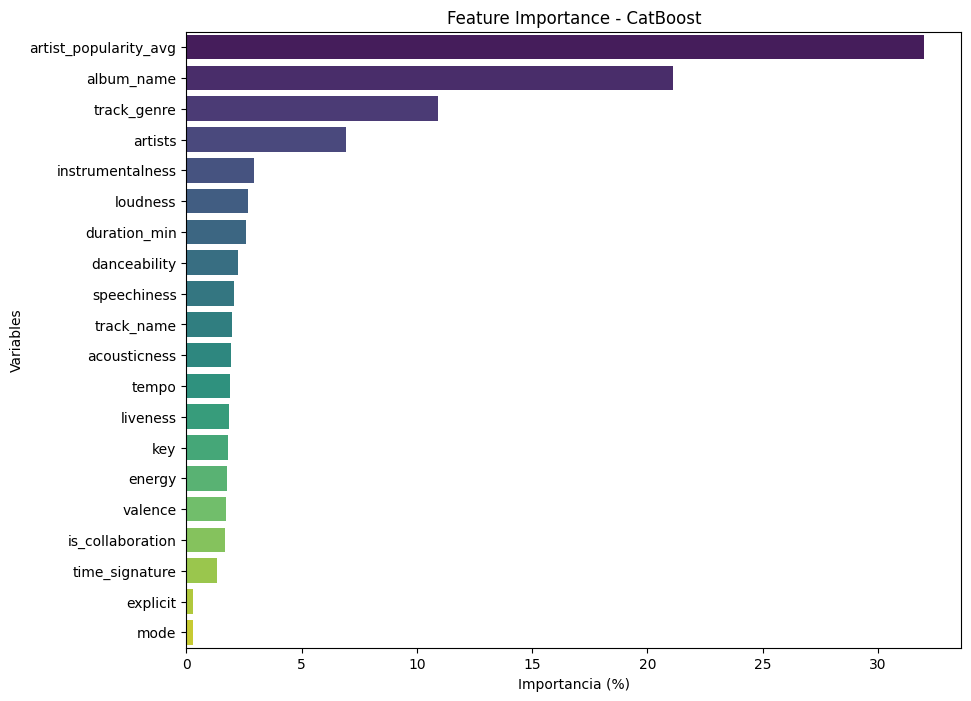

,Popularity
0,47.628797
1,12.975324
2,0.120710
3,-0.383773
4,25.290456


In [111]:
vars_categoricas = var_categoricas + vars_cat_num + ['is_collaboration']
train_pool = Pool(X_train_D, y_train, cat_features=vars_categoricas)
val_pool = Pool(X_val_D, y_val, cat_features=vars_categoricas)

model = CatBoostRegressor(iterations=1500, learning_rate=0.07, depth=10, l2_leaf_reg=1, early_stopping_rounds=100, border_count=254, eval_metric='RMSE', random_seed=42, verbose=100)
model.fit(train_pool)

y_pred_cat = model.predict(val_pool)
mse_cat = metrics.mean_squared_error(y_val, y_pred_cat)
rmse_cat = np.sqrt(mse_cat)
display(Markdown(f"""Se obtiene que el modelo resultante cuenta con un RMSE de {rmse_cat:.4f} y MSE de {mse_cat:.4f}"""))

importancia = model.get_feature_importance()
nombres_vars = X_train_D.columns

df_importancia = pd.DataFrame({
    'Feature': nombres_vars,
    'Importance': importancia
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=df_importancia, palette='viridis')
plt.title('Feature Importance - CatBoost')
plt.xlabel('Importancia (%)')
plt.ylabel('Variables')
plt.show()

test_pool = Pool(x_test_D, cat_features=vars_categoricas)
y_pred_cat_test = model.predict(test_pool)

y_pred_test_final = pd.DataFrame(y_pred_cat_test, index=x_test_D.index, columns=['Popularity'])
y_pred_test_final.to_csv('CatBoost5.csv', index_label='ID')
y_pred_test_final.head()

## 2.2 RandomForest - Set B

Fitting 3 folds for each of 10 candidates, totalling 30 fits


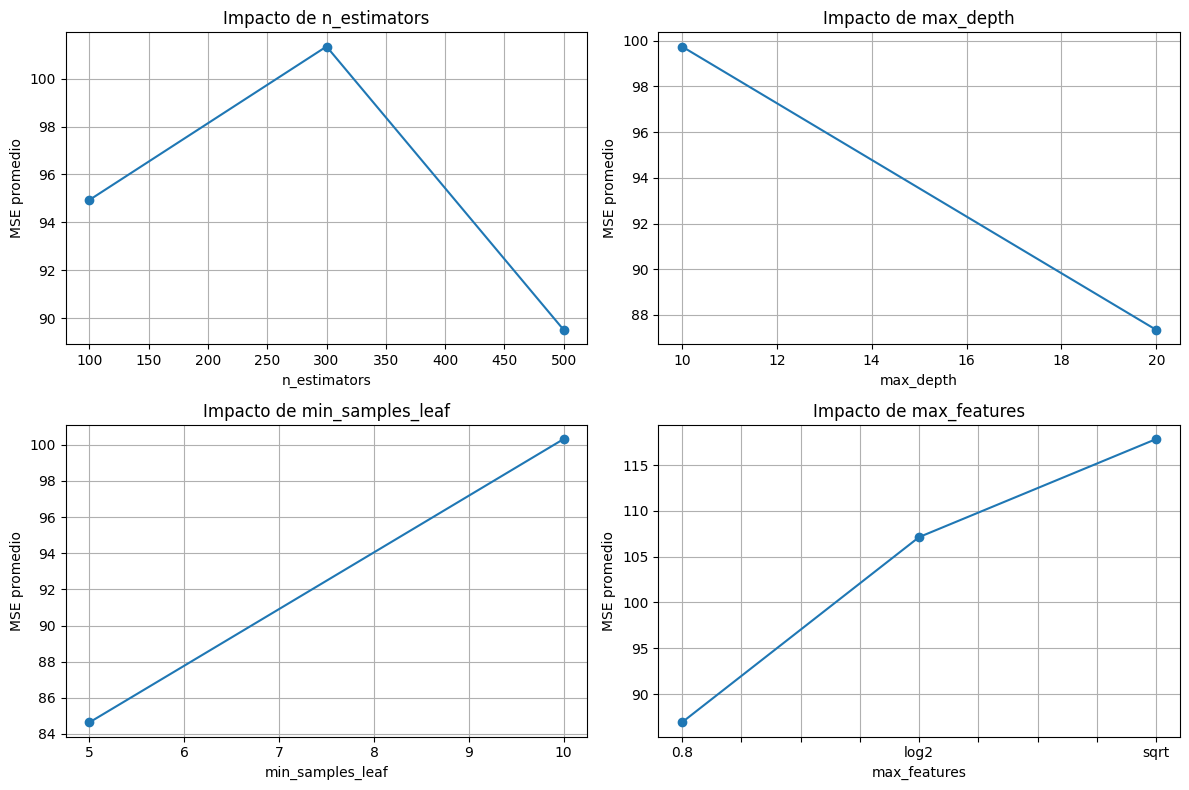

**Mejores parámetros encontrados:**
- n_estimators = 500
- max_depth = 20
- min_samples_leaf = 5
- max_features = 0.8
MSE mínimo: 79.5010

Se obtiene que el modelo resultante cuenta con un RMSE de 11.2927 y MSE de 127.5255

In [109]:
param_dist_rf = {
    'n_estimators': [100, 300, 500],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [5, 10],
    'max_features': ['sqrt', 'log2', 0.8]
}

rf_search = RandomForestRegressor(random_state=22, n_jobs=-1)
rs_rf = RandomizedSearchCV(rf_search, param_distributions=param_dist_rf, n_iter=10, scoring='neg_mean_squared_error', cv=3, verbose=1, random_state=22)
rs_rf.fit(X_train_B, y_train)
best_rf = rs_rf.best_estimator_
best_mse = -rs_rf.best_score_

results_rf = pd.DataFrame(rs_rf.cv_results_)
results_rf['mean_mse'] = -results_rf['mean_test_score']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes_flat = axes.flatten()
parametros_rf = ['n_estimators', 'max_depth', 'min_samples_leaf', 'max_features']

for i, param in enumerate(parametros_rf):
    col_name = f'param_{param}'
    results_rf.groupby(col_name)['mean_mse'].mean().plot(kind='line', marker='o', ax=axes_flat[i])
    axes_flat[i].set_title(f'Impacto de {param}')
    axes_flat[i].set_xlabel(param)
    axes_flat[i].set_ylabel('MSE promedio')
    axes_flat[i].grid(True)

plt.tight_layout()
plt.show()

display(Markdown(f"""**Mejores parámetros encontrados:**
- n_estimators = {best_rf.n_estimators}
- max_depth = {best_rf.max_depth}
- min_samples_leaf = {best_rf.min_samples_leaf}
- max_features = {best_rf.max_features}
MSE mínimo: {best_mse:.4f}"""))

clf_rf = RandomForestRegressor(n_estimators=best_rf.n_estimators, max_depth=best_rf.max_depth , min_samples_leaf=best_rf.min_samples_leaf, 
                               max_features=best_rf.max_features, n_jobs=-1)
clf_rf.fit(X_train_B, y_train)
y_pred_rf = clf_rf.predict(X_val_B)
mse_rf = metrics.mean_squared_error(y_val, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
display(Markdown(f"""Se obtiene que el modelo resultante cuenta con un RMSE de {rmse_rf:.4f} y MSE de {mse_rf:.4f}"""))

## 2.3 LightGBM - Set C

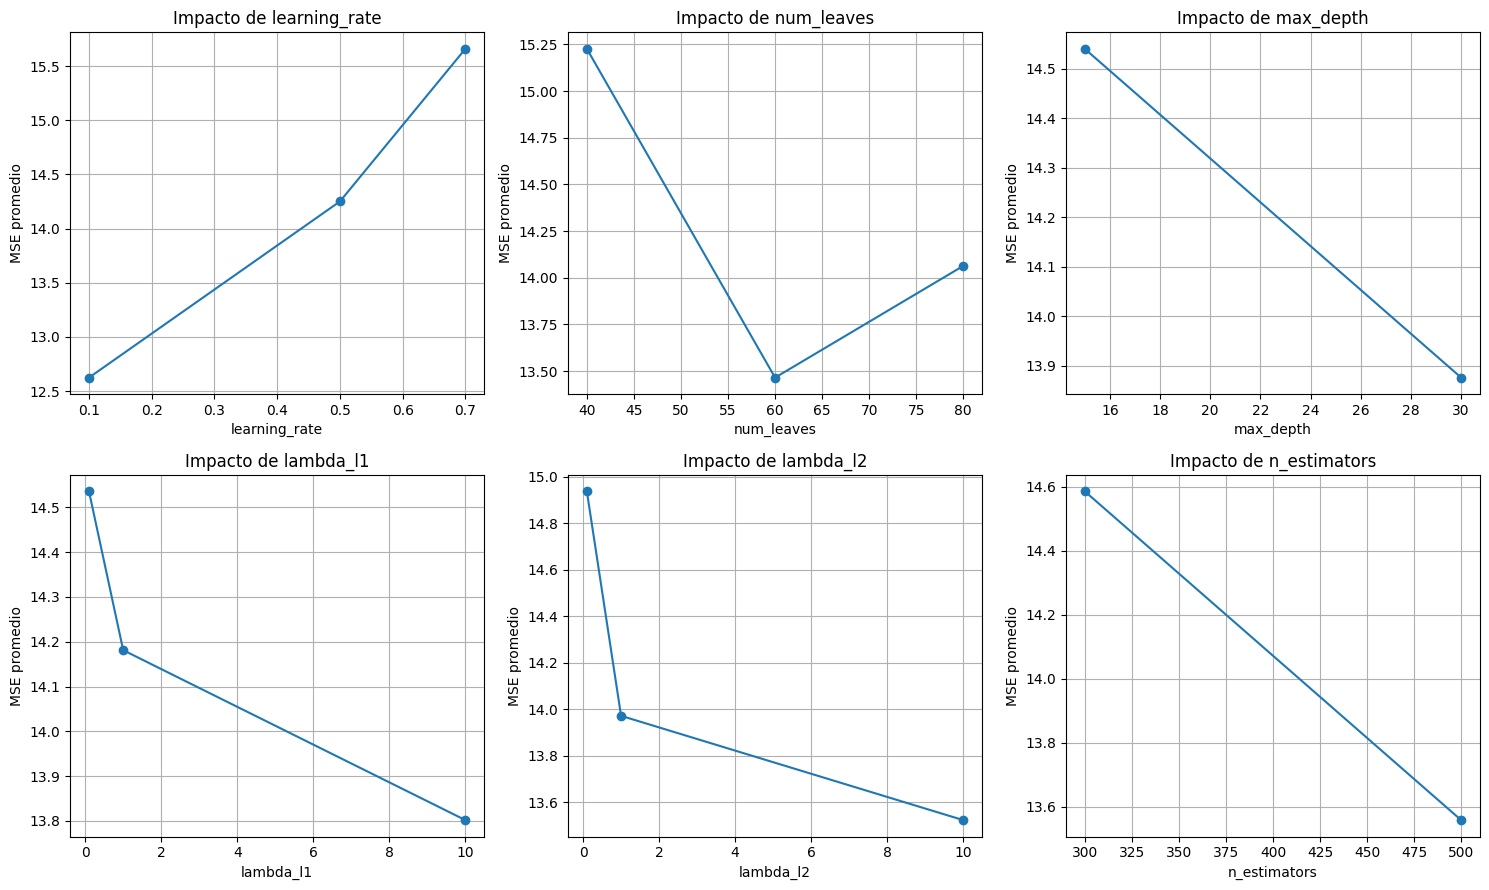

**Mejores parámetros encontrados:**
- n_estimators = 300
- learning_rate = 0.1
- num_leaves = 80
- max_depth = 15
- lambda_l1 = 1
- lambda_l2 = 1
- feature_fraction = 0.9
MSE mínimo: 12.3905

Se obtiene que el modelo resultante cuenta con un RMSE de 11.4820 y MSE de 131.8373

In [107]:
param_lgb = {
    'n_estimators': [300, 500],
    'learning_rate': [0.1, 0.5, 0.7],
    'num_leaves': [40, 60, 80],
    'max_depth': [15, 30],
    'lambda_l1': [0.1, 1, 10],
    'lambda_l2': [0.1, 1, 10],
    'feature_fraction': [0.7, 0.9]
}

lgbm_search = LGBMRegressor(early_stopping_rounds=10, random_state=23, verbose=-1, n_jobs=-1)
rs_lgbm = RandomizedSearchCV(lgbm_search,  param_distributions=param_lgb, n_iter=20, scoring='neg_mean_squared_error', cv=3, verbose=0, random_state=23)
rs_lgbm.fit(X_train_C, y_train, eval_set=[(X_val_C, y_val)], eval_metric='mse')
best_lgbm = rs_lgbm.best_estimator_
best_mse = -rs_lgbm.best_score_

results_lgb = pd.DataFrame(rs_lgbm.cv_results_)
results_lgb['mean_mse'] = -results_lgb['mean_test_score']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes_flat = axes.flatten()
parametros_lgb = ['learning_rate', 'num_leaves', 'max_depth', 'lambda_l1', 'lambda_l2', 'n_estimators']

for i, param in enumerate(parametros_lgb):
    col_name = f'param_{param}'
    results_lgb.groupby(col_name)['mean_mse'].mean().plot(kind='line', marker='o', ax=axes_flat[i])
    axes_flat[i].set_title(f'Impacto de {param}')
    axes_flat[i].set_xlabel(param)
    axes_flat[i].set_ylabel('MSE promedio')
    axes_flat[i].grid(True)

plt.tight_layout()
plt.show()

display(Markdown(f"""**Mejores parámetros encontrados:**
- n_estimators = {best_lgbm.n_estimators}
- learning_rate = {best_lgbm.learning_rate}
- num_leaves = {best_lgbm.num_leaves}
- max_depth = {best_lgbm.max_depth}
- lambda_l1 = {best_lgbm.lambda_l1}
- lambda_l2 = {best_lgbm.lambda_l2}
- feature_fraction = {best_lgbm.feature_fraction}
MSE mínimo: {best_mse:.4f}"""))

clf_lgb = LGBMRegressor(n_estimators=best_lgbm.n_estimators, learning_rate=best_lgbm.learning_rate, num_leaves=best_lgbm.num_leaves, 
                        max_depth=best_lgbm.max_depth, lambda_l1=best_lgbm.lambda_l1, lambda_l2= best_lgbm.lambda_l2, 
                        feature_fraction=best_lgbm.feature_fraction, n_jobs=-1)
clf_lgb.fit(X_train_C, y_train)
y_pred_lgb = clf_lgb.predict(X_val_C)
mse_lgb = metrics.mean_squared_error(y_val, y_pred_lgb)
rmse_lgb = np.sqrt(mse_lgb)
display(Markdown(f"""Se obtiene que el modelo resultante cuenta con un RMSE de {rmse_lgb:.4f} y MSE de {mse_lgb:.4f}"""))

In [ ]:


cat_features_idx = [X_train_C.columns.get_loc(col) for col in var_categoricas]
print("Índices categóricos:", cat_features_idx)

param_grid = {
    'n_estimators': [300, 500, 800],
    'learning_rate': [0.03, 0.05, 0.1],
    'depth': [4, 6, 8],
    'l2_leaf_reg': [1, 3, 5, 7]
}


clf = CatBoostRegressor(random_state=42,verbose=False,loss_function='RMSE')

grid_search = GridSearchCV(estimator=clf,param_grid=param_grid,cv=5,scoring='neg_mean_squared_error',n_jobs=-1,verbose=1)
grid_search.fit(X_train_C, y_train, cat_features=cat_features_idx)
best_params = grid_search.best_params_
best_mse = -grid_search.best_score_


results = pd.DataFrame(grid_search.cv_results_)
results['mean_mse'] = -results['mean_test_score']


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Impacto de n_estimators
mask_ne = (
    (results['param_depth'] == best_params['depth']) &
    (results['param_l2_leaf_reg'] == best_params['l2_leaf_reg']) &
    (results['param_learning_rate'] == best_params['learning_rate'])
)
results[mask_ne].groupby('param_n_estimators')['mean_mse'].mean().plot(ax=axes[0, 0], marker='o')
axes[0, 0].set_title('Impacto de n_estimators')
axes[0, 0].set_xlabel('n_estimators')
axes[0, 0].set_ylabel('MSE promedio')
axes[0, 0].grid(True)

# Impacto de depth
mask_d = (
    (results['param_n_estimators'] == best_params['n_estimators']) &
    (results['param_l2_leaf_reg'] == best_params['l2_leaf_reg']) &
    (results['param_learning_rate'] == best_params['learning_rate'])
)
results[mask_d].groupby('param_depth')['mean_mse'].mean().plot(ax=axes[0, 1], marker='o')
axes[0, 1].set_title('Impacto de depth')
axes[0, 1].set_xlabel('depth')
axes[0, 1].set_ylabel('MSE promedio')
axes[0, 1].grid(True)

# Impacto de l2_leaf_reg
mask_l2 = (
    (results['param_n_estimators'] == best_params['n_estimators']) &
    (results['param_depth'] == best_params['depth']) &
    (results['param_learning_rate'] == best_params['learning_rate'])
)
results[mask_l2].groupby('param_l2_leaf_reg')['mean_mse'].mean().plot(ax=axes[1, 0], marker='o')
axes[1, 0].set_title('Impacto de l2_leaf_reg')
axes[1, 0].set_xlabel('l2_leaf_reg')
axes[1, 0].set_ylabel('MSE promedio')
axes[1, 0].grid(True)

# Impacto de learning_rate
mask_lr = (
    (results['param_n_estimators'] == best_params['n_estimators']) &
    (results['param_depth'] == best_params['depth']) &
    (results['param_l2_leaf_reg'] == best_params['l2_leaf_reg'])
)
results[mask_lr].groupby('param_learning_rate')['mean_mse'].mean().plot(ax=axes[1, 1], marker='o')
axes[1, 1].set_title('Impacto de learning_rate')
axes[1, 1].set_xlabel('learning_rate')
axes[1, 1].set_ylabel('MSE promedio')
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()


display(Markdown(f"""**Mejores parámetros encontrados:**
- n_estimators = {best_params['n_estimators']}
- depth = {best_params['depth']}
- learning_rate = {best_params['learning_rate']}
- l2_leaf_reg = {best_params['l2_leaf_reg']}

**MSE mínimo:** {best_mse:.4f}  
**RMSE mínimo:** {best_mse**0.5:.4f}
"""))

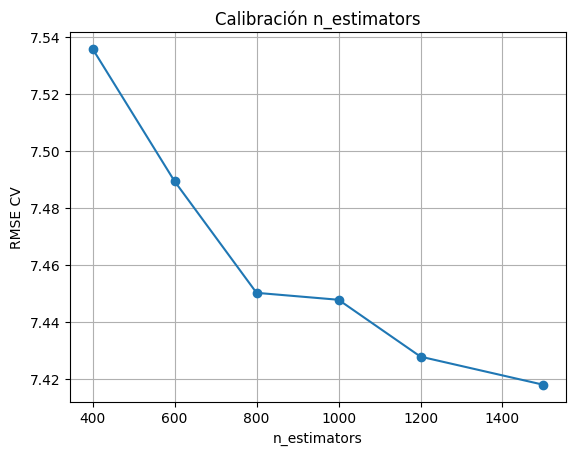

Mejor n_estimators: 1500


In [20]:
cat_features_idx = [X_train_D.columns.get_loc(col) for col in var_categoricas]

n_estimators_range = [400, 600, 800, 1000, 1200, 1500]

rmse_scores = []

for n in n_estimators_range:
    
    modelo = CatBoostRegressor(
        random_state=42,
        verbose=False,
        loss_function='RMSE',
        n_estimators=n,

    )
    
    mse_cv = -cross_val_score(
        modelo,
        X_train_D,
        y_train,
        cv=3,
        scoring='neg_mean_squared_error',
        params={'cat_features': cat_features_idx}
    ).mean()
    
    rmse_scores.append(np.sqrt(mse_cv))

plt.plot(n_estimators_range, rmse_scores, marker="o")
plt.xlabel("n_estimators")
plt.ylabel("RMSE CV")
plt.title("Calibración n_estimators")
plt.grid(True)
plt.show()

best_n_estimators = n_estimators_range[np.argmin(rmse_scores)]

print("Mejor n_estimators:", best_n_estimators)

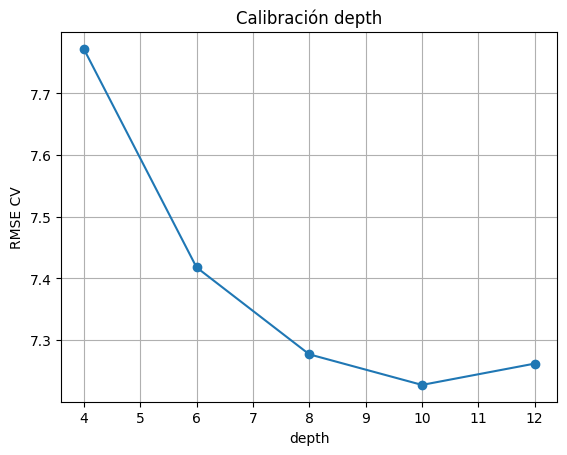

Mejor depth: 10


In [21]:
cat_features_idx = [X_train_D.columns.get_loc(col) for col in var_categoricas]

depth_range = [4, 6, 8, 10, 12]

rmse_scores = []

for d in depth_range:
    
    modelo = CatBoostRegressor(
        random_state=42,
        verbose=False,
        loss_function='RMSE',
        n_estimators=1500,
        depth=d
    )
    
    mse_cv = -cross_val_score(
        modelo,
        X_train_D,
        y_train,
        cv=3,
        scoring='neg_mean_squared_error',
        params={'cat_features': cat_features_idx}
    ).mean()
    
    rmse_scores.append(np.sqrt(mse_cv))

# gráfica

plt.plot(depth_range, rmse_scores, marker="o")
plt.xlabel("depth")
plt.ylabel("RMSE CV")
plt.title("Calibración depth")
plt.grid(True)
plt.show()

best_depth = depth_range[np.argmin(rmse_scores)]

print("Mejor depth:", best_depth)

In [ ]:
# Índices categóricos
cat_features_idx = [X_train_C.columns.get_loc(col) for col in var_categoricas]

# Modelo con parámetros fijos
modelo_cat = CatBoostRegressor(
    random_state=42,
    verbose=False,
    loss_function='RMSE',
    n_estimators=1500,
    depth=8,
    learning_rate=0.1,
    l2_leaf_reg=1,
    # random_strength = 10,
    # min_data_in_leaf = 10,
    # one_hot_max_size = 25,
    # max_ctr_complexity = 3
)

# Entrenamiento
modelo_cat.fit(
    X_train_C,
    y_train,
    cat_features=cat_features_idx
)

# Predicción (validation o test)
y_pred = modelo_cat.predict(X_val_C)

# Métricas
mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)

# Reporte
display(Markdown(f"""
### Evaluación del modelo CatBoost (parámetros fijos)

Parámetros:

- n_estimators = 1500
- depth = 8
- learning_rate = 0.1
- l2_leaf_reg = 1


Resultados:

- MSE = {mse:.4f}
- RMSE = {rmse:.4f}
"""))

# pred_cat_test = modelo_cat.predict(x_test_D)

# pred_cat_test = np.maximum(0, pred_cat_test)

# pred_cat_test_df = pd.DataFrame(
#     pred_cat_test,
#     index=data_Testing.index,
#     columns=['Popularity']
# )

# pred_cat_test_df.to_csv('CatBoost6.csv', index_label='ID')
# pred_cat_test_df.head()

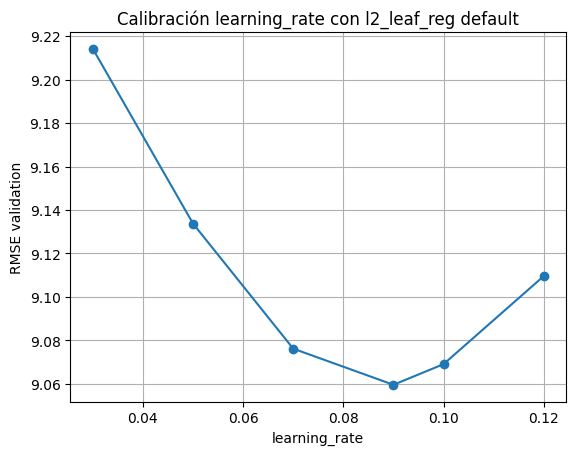

Mejor learning_rate: 0.09


In [22]:
learning_rate_range = [0.03, 0.05, 0.07, 0.09, 0.1, 0.12]

rmse_scores_lr = []

for lr in learning_rate_range:
    
    modelo_cat = CatBoostRegressor(
        random_state=42,
        verbose=False,
        loss_function='RMSE',
        n_estimators=1500,
        depth=8,
        learning_rate=lr
    )
    
    modelo_cat.fit(
        X_train_C,
        y_train,
        cat_features=cat_features_idx
    )
    
    y_pred = modelo_cat.predict(X_val_C)
    
    mse = mean_squared_error(y_val, y_pred)
    rmse = np.sqrt(mse)
    
    rmse_scores_lr.append(rmse)

plt.plot(learning_rate_range, rmse_scores_lr, marker="o")
plt.xlabel("learning_rate")
plt.ylabel("RMSE validation")
plt.title("Calibración learning_rate con l2_leaf_reg default")
plt.grid(True)
plt.show()

best_learning_rate = learning_rate_range[np.argmin(rmse_scores_lr)]

print("Mejor learning_rate:", best_learning_rate)

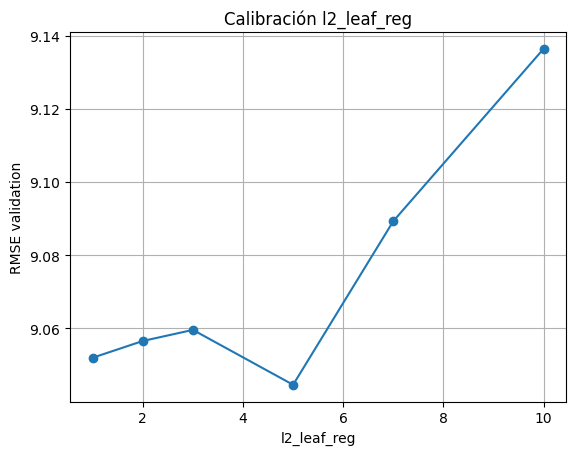

Mejor l2_leaf_reg: 5


In [23]:
l2_range = [1, 2, 3, 5, 7, 10]

rmse_scores_l2 = []

for l2 in l2_range:
    
    modelo_cat = CatBoostRegressor(
        random_state=42,
        verbose=False,
        loss_function='RMSE',
        n_estimators=1500,
        depth=8,
        learning_rate=best_learning_rate,
        l2_leaf_reg=l2
    )
    
    modelo_cat.fit(
        X_train_C,
        y_train,
        cat_features=cat_features_idx
    )
    
    y_pred = modelo_cat.predict(X_val_C)
    
    mse = mean_squared_error(y_val, y_pred)
    rmse = np.sqrt(mse)
    
    rmse_scores_l2.append(rmse)

plt.plot(l2_range, rmse_scores_l2, marker="o")
plt.xlabel("l2_leaf_reg")
plt.ylabel("RMSE validation")
plt.title("Calibración l2_leaf_reg")
plt.grid(True)
plt.show()

best_l2 = l2_range[np.argmin(rmse_scores_l2)]

print("Mejor l2_leaf_reg:", best_l2)

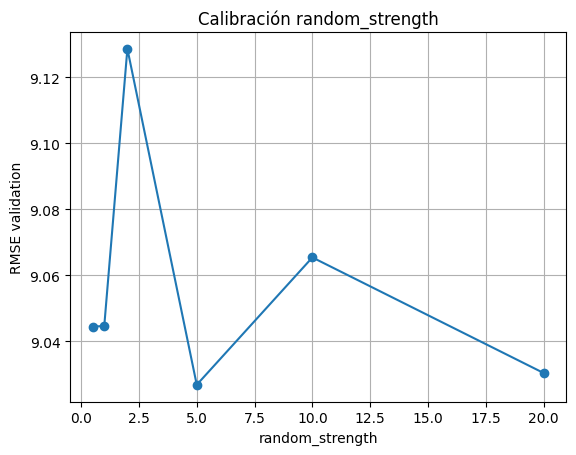

Mejor random_strength: 5


In [ ]:
random_strength_range = [0.5, 1, 2, 5, 10, 20]

rmse_scores_rs = []

for rs in random_strength_range:
    
    modelo_cat = CatBoostRegressor(
        random_state=42,
        verbose=False,
        loss_function='RMSE',
        n_estimators=1500,
        depth=8,
        learning_rate=best_learning_rate,
        l2_leaf_reg=best_l2,
        random_strength=rs
    )
    
    modelo_cat.fit(
        X_train_C,
        y_train,
        cat_features=cat_features_idx
    )
    
    y_pred = modelo_cat.predict(X_val_C)
    
    mse = mean_squared_error(y_val, y_pred)
    rmse = np.sqrt(mse)
    
    rmse_scores_rs.append(rmse)

plt.plot(random_strength_range, rmse_scores_rs, marker="o")
plt.xlabel("random_strength")
plt.ylabel("RMSE validation")
plt.title("Calibración random_strength")
plt.grid(True)
plt.show()

best_random_strength = random_strength_range[np.argmin(rmse_scores_rs)]

print("Mejor random_strength:", best_random_strength)

In [27]:
modelo_cat = CatBoostRegressor(
    random_state=42,
    verbose=False,
    loss_function='RMSE',
    n_estimators=1500,
    depth=8,
    learning_rate=0.09,
    l2_leaf_reg=5,
    random_strength=5
)

# entrenamiento
modelo_cat.fit(
    X_train_C,
    y_train,
    cat_features=cat_features_idx
)

# predicción validation
y_pred = modelo_cat.predict(X_val_C)

# métricas
mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)

# reporte limpio
display(Markdown(f"""
### Evaluación modelo CatBoost calibrado

Parámetros finales:

- n_estimators = {modelo_cat.get_param('n_estimators')}
- depth = {modelo_cat.get_param('depth')}
- learning_rate = {modelo_cat.get_param('learning_rate')}
- l2_leaf_reg = {modelo_cat.get_param('l2_leaf_reg')}
- random_strength = {modelo_cat.get_param('random_strength')}

Resultados (validation):

- MSE = {mse:.4f}
- RMSE = {rmse:.4f}
"""))


### Evaluación modelo CatBoost calibrado

Parámetros finales:

- n_estimators = 1500
- depth = 8
- learning_rate = 0.09
- l2_leaf_reg = 5
- random_strength = 5

Resultados (validation):

- MSE = 81.4827
- RMSE = 9.0268


In [28]:

seeds = [
    1, 3, 5, 7, 9,
    11, 13, 17, 21, 29,
    33, 42, 57, 72, 88,
    99, 123, 202, 404, 777
]

resultados_seed = []

for seed in seeds:

    modelo_cat = CatBoostRegressor(
        random_state=seed,
        verbose=False,
        loss_function='RMSE',
        n_estimators=1500,
        depth=8,
        learning_rate=0.09,
        l2_leaf_reg=5,
        random_strength=5
    )

    modelo_cat.fit(
        X_train_C,
        y_train,
        cat_features=cat_features_idx
    )

    y_pred = modelo_cat.predict(X_val_C)

    mse = mean_squared_error(y_val, y_pred)
    rmse = np.sqrt(mse)

    resultados_seed.append({
        "seed": seed,
        "mse": mse,
        "rmse": rmse,
        "modelo": modelo_cat
    })

df_seeds = pd.DataFrame(resultados_seed).sort_values("rmse")

display(df_seeds.drop(columns="modelo"))

best_seed = df_seeds.iloc[0]["seed"]
best_rmse = df_seeds.iloc[0]["rmse"]
best_mse = df_seeds.iloc[0]["mse"]
best_model = df_seeds.iloc[0]["modelo"]

display(Markdown(f"""
### Mejor seed encontrada (20 seeds probadas)

Parámetros:

- random_state = {int(best_seed)}
- n_estimators = 1500
- depth = 8
- learning_rate = 0.09
- l2_leaf_reg = 5
- random_strength = 5

Resultados validation:

- MSE = {best_mse:.4f}
- RMSE = {best_rmse:.4f}
"""))

,seed,mse,rmse
6,13,80.882789,8.993486
5,11,81.155596,9.008640
19,777,81.193481,9.010743
11,42,81.482677,9.026776
3,7,81.565633,9.031369
0,1,81.612998,9.033991
8,21,81.697145,9.038647
15,99,81.723298,9.040094
13,72,81.822057,9.045555
9,29,82.059537,9.058672



### Mejor seed encontrada (20 seeds probadas)

Parámetros:

- random_state = 13
- n_estimators = 1500
- depth = 8
- learning_rate = 0.09
- l2_leaf_reg = 5
- random_strength = 5

Resultados validation:

- MSE = 80.8828
- RMSE = 8.9935


In [ ]:
# Índices categóricos
cat_features_idx = [X_train_D.columns.get_loc(col) for col in var_categoricas]

modelo_cat = CatBoostRegressor(
    random_state=13,
    verbose=False,
    loss_function='RMSE',
    n_estimators=1500,
    depth=10,
    learning_rate=0.09,
    l2_leaf_reg=5,
    random_strength = 5,
)

modelo_cat.fit(
    X_train_D,
    y_train,
    cat_features=cat_features_idx
)

# Predicción (validation o test)
y_pred = modelo_cat.predict(X_val_D)

# Métricas
mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)

# Reporte
display(Markdown(f"""
### Evaluación del modelo CatBoost (parámetros fijos)

Parámetros:

- n_estimators = 1500
- depth = 10
- learning_rate = 0.09
- l2_leaf_reg = 5
- random_strength = 5
-random_state = 13

Resultados:

- MSE = {mse:.4f}
- RMSE = {rmse:.4f}
"""))

pred_cat_test = modelo_cat.predict(x_test_D)

pred_cat_test = np.maximum(0, pred_cat_test)

pred_cat_test_df = pd.DataFrame(
    pred_cat_test,
    index=data_Testing.index,
    columns=['Popularity']
)

pred_cat_test_df.to_csv('CatBoost7.csv', index_label='ID')
pred_cat_test_df.head()


### Evaluación del modelo CatBoost (parámetros fijos)

Parámetros:

- n_estimators = 1500
- depth = 8
- learning_rate = 0.09
- l2_leaf_reg = 5
- random_strength = 5
-random_state = 13

Resultados:

- MSE = 80.0057
- RMSE = 8.9446


,Popularity
0,44.985648
1,14.804757
2,0.000000
3,0.000000
4,23.989338


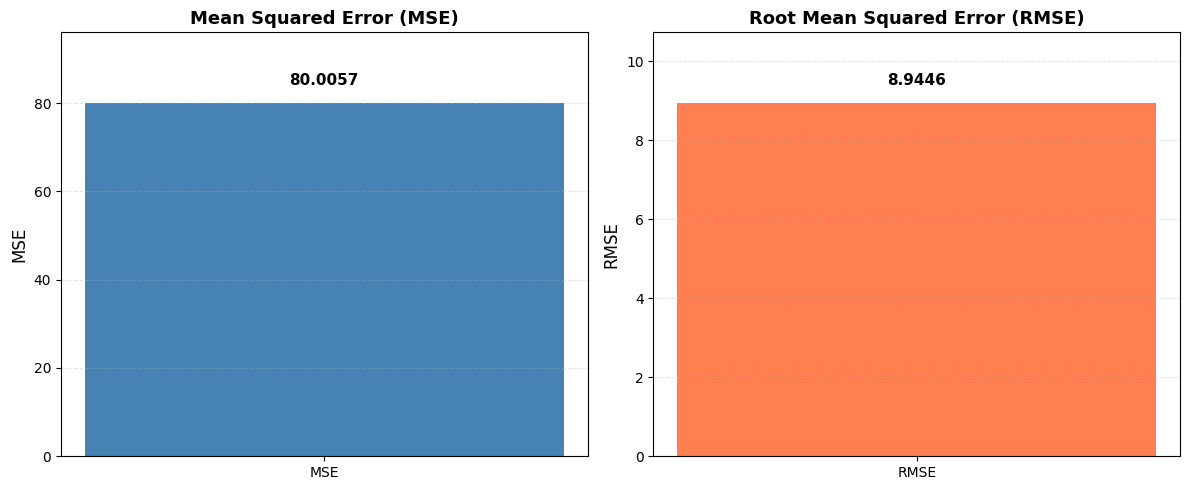

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))


axes[0].bar(['MSE'], [mse], color='steelblue', width=0.5)
axes[0].set_ylabel('MSE', fontsize=12)
axes[0].set_title('Mean Squared Error (MSE)', fontsize=13, fontweight='bold')
axes[0].set_ylim(0, mse * 1.2)
for i, v in enumerate([mse]):
    axes[0].text(i, v + mse*0.05, f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')
axes[0].grid(axis='y', linestyle='--', alpha=0.3)

axes[1].bar(['RMSE'], [rmse], color='coral', width=0.5)
axes[1].set_ylabel('RMSE', fontsize=12)
axes[1].set_title('Root Mean Squared Error (RMSE)', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, rmse * 1.2)
for i, v in enumerate([rmse]):
    axes[1].text(i, v + rmse*0.05, f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')
axes[1].grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Entrenamiento del modelo
## 3.1 Ensamble - Votación Ponderada

In [111]:
# 2. Definición de Pesos (Weights)
w_cat = 0.75
w_rf  = 0.15
w_lgb = 0.10

y_pred_ensemble_val = (w_cat * y_pred_cat) + (w_rf * y_pred_rf) + (w_lgb * y_pred_lgb)

mse_final = mean_squared_error(y_val, y_pred_ensemble_val)
rmse_final = np.sqrt(mse_final)
display(Markdown(f"""Se obtiene que el modelo resultante del ensamble por votación ponderaa cuenta con un RMSE de {rmse_final:.4f} y MSE de {mse_final:.4f}"""))

# Generamos las predicciones individuales para el Test
pred_cat_test = modelo_cat.predict(x_test_D)
pred_rf_test  = best_rf.predict(x_test_B)
pred_lgb_test = best_lgbm.predict(X_test_C.select_dtypes(exclude=['object']))

y_pred_test_final = (w_cat * pred_cat_test) + (w_rf * pred_rf_test) + (w_lgb * pred_lgb_test)
y_pred_test_final = np.maximum(0, y_pred_test_final)

y_pred_test_final_df = pd.DataFrame(y_pred_test_final, index=data_Testing.index, columns=['Popularity'])
y_pred_test_final_df.to_csv('Ensamble_CB_RF_LGBM.csv', index_label='ID')
y_pred_test_final_df.head()

Se obtiene que el modelo resultante del ensamble por votación ponderaa cuenta con un RMSE de 9.4655 y MSE de 89.5965

,Popularity
0,43.397995
1,13.198678
2,1.227422
3,0.015236
4,26.438315


# 4. Disponibilización del modelo